In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation

# Inhoud

1. [Introductie en specificaties](#intro)
2. [Ontwerp van de nokgeometrie](#geometrie)
3. [Inverse dynamica en nokveer](#dynamica)
4. [Prestaties en verificatie](#verificatie)
5. [Finale ontwerpwaarden en checklist](#finale-waarden)
6. [Referenties](#referenties)

<a id="intro"></a>
# 1. Introductie en Specificaties
## 1.1 Nokken-ontwerp: specificaties
Gegevens : De te ontwerpen nok moet volgende heffing kunnen realiseren :

1. van 45° tot 90° : +5 mm
2. van 90° tot 180° : +15 mm
3. van 180° tot 305° : -20 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 15 kg en 0.055, terwijl het mechanisme volgende statische krachten moet uitoefenen:

1. van 45° tot 90° : een konstante druk-kracht van 250 N
2. van 90° tot 180° : een lineair toenemende druk-kracht van 250 N tot 1050 N
3. van 180° tot 250° : een konstante trek-kracht van 300 N

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.3 sec.

Hieronder tonen we de gegeven specs in een grafiek van de positie en de kracht

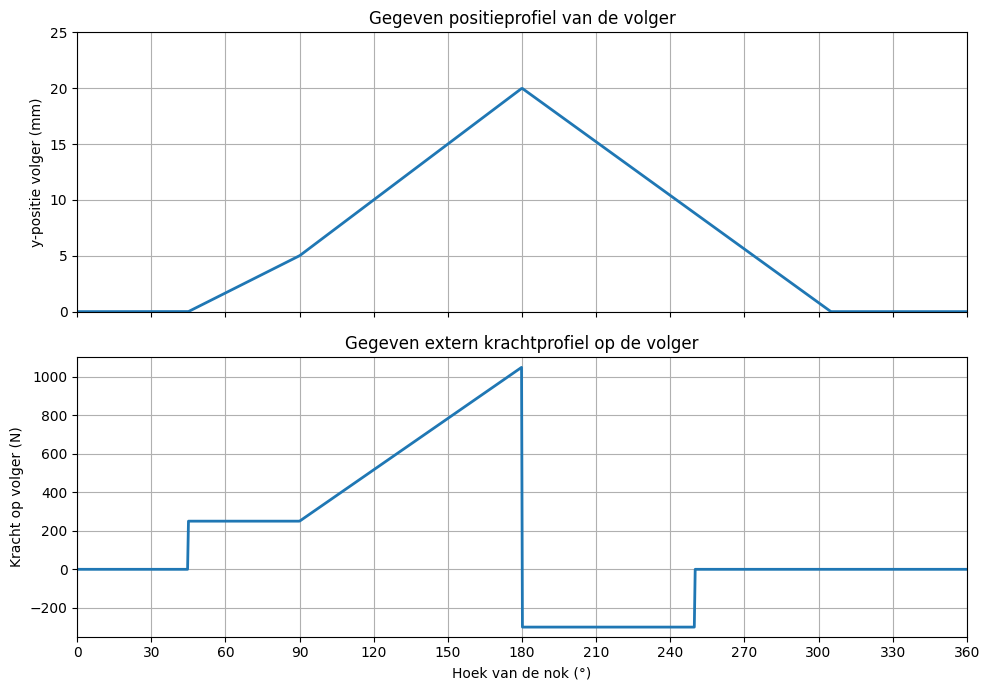

In [2]:
"""
Gegeven specificaties
"""

theta_given_deg = np.linspace(0, 360, 1000)   # hoek van de nok °

F_pre = 250    #N
F_max = 1050   #N
F_pull = -300  #N

theta_pull_end = 250 #°

"""
Positieprofiel y(theta)
"""
lift_given = np.zeros_like(theta_given_deg)

# 45°-90°: 0mm - 5mm
mask = (theta_given_deg >= 45) & (theta_given_deg < 90)
lift_given[mask] = (theta_given_deg[mask] - 45) / (90 - 45) * 5

# 90°-180°: 5mm - 20mm
mask = (theta_given_deg >= 90) & (theta_given_deg < 180)
lift_given[mask] = 5 + (theta_given_deg[mask] - 90) / (180 - 90) * 15

# 180°-305°: van 20mm - 0mm
mask = (theta_given_deg >= 180) & (theta_given_deg < 305)
lift_given[mask] = 20 - (theta_given_deg[mask] - 180) / (305 - 180) * 20

# 0°-45° en 305°-360° blijven 0mm

"""
Externe kracht F(theta)
"""
F = np.zeros_like(theta_given_deg)

# 45° - 90°: cte drukkracht
mask = (theta_given_deg >= 45) & (theta_given_deg < 90)
F[mask] = F_pre

# 90° - 180°: lineair stijgend van F_pre naar F_max
mask = (theta_given_deg >= 90) & (theta_given_deg < 180)
F[mask] = F_pre + (theta_given_deg[mask] - 90) / (180 - 90) * (F_max - F_pre)

# 180° - theta_pull_end: cte trekkracht
mask = (theta_given_deg >= 180) & (theta_given_deg < theta_pull_end)
F[mask] = F_pull

# Na theta_pull_end blijft de kracht 0 N

"""
# Grafieken
"""
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Grafiek 1: positie
axs[0].plot(theta_given_deg, lift_given, linewidth=2)
axs[0].set_ylabel("y-positie volger (mm)")
axs[0].set_title("Gegeven positieprofiel van de volger")
axs[0].set_xlim(0, 360)
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Grafiek 2: kracht
axs[1].plot(theta_given_deg, F, linewidth=2)
axs[1].set_xlabel("Hoek van de nok (°)")
axs[1].set_ylabel("Kracht op volger (N)")
axs[1].set_title("Gegeven extern krachtprofiel op de volger")
axs[1].set_xlim(0, 360)
axs[1].set_ylim(-350, 1100)
axs[1].set_xticks(np.arange(0, 361, 30))
axs[1].grid(True)

plt.tight_layout()
plt.show()

## 1.2: Toepassing - Tablet Press

Op basis van het krachtenprofiel dachten we een soort stempelmachine te maken. Dit past goed bij een nokmechanisme, omdat de gewenste beweging periodiek is en omdat de kracht sterk afhankelijk is van de positie van de stempel .Omdat de krachten niet ongelofelijk hoog zijn was de toepassing tablet press voor de farmaseutische industrie boven gekomen. Hieronder is een schets van de verschillende stappen met daaronder uitleg.

<p align="center">
  <img src="Images\visualisatie_compressie.png" width="700"><br>
  <b>Figuur 1:</b> Visualie compressiestappen
</p>

#### Positie 1: Rust
*Hoeken: 305°-45°*

De stempel blijft zijn positie houden en ondervind geen externe krachten. Tijdens deze fase wordt de afgemaakte pil afgevoerd en een nieuwe matrijs gevuld met poeder klaargezet voor de volgende compressie.

#### Positie 2: Plaatsing stempel
*Hoek: $\theta_1$*

De stempel in rust is 2.5mm verwijderd van de opening van de matrijs. Van positie 1 naar positie 2 verplaatst de stempel dus +2.5mm zonder kracht te ondervinden. De reden dat deze hoek $\theta_1$ wordt genoemd is omdat uiteindelijk het verplaatsingsprofiel wordt verzacht om minder sterke schokken te krijgen (deze moet dus berekend worden).

#### Positie 3: Indrukken stempel
*Hoek: 90°*

De stempel positioneert zich 2.5mm in de matrijs (afmaken van 5mm verplaatsing). Binnen de matrijs in de neerwaarste slag zal de stempel een constante tegenwerkende wrijving [1](#ref1) van 250N ondervinden (daarom dat van 1 $\rightarrow$ 3 opgesplitst moest worden). De kleine compressie van de poeder die hier gebeurt wordt verwaarloosd.

#### Positie 4: Compressie + Dwell
*Hoeken: 150°-180°*

Van 90°-150° is de compressieslag van de stempel waar de stempel 15mm in de matrijs wordt geduwd. Compressie wordt gemodelleerd als evenredig met de samendrukking en dus lineair toenemend tot 1050N. Hierbovenop wordt de wrijving in de matrijs gesuperponeerd.

Van 150°-180° blijft de stempel op dezelfde positie. Dit heet dwelling en zorgt ervoor dat er minder kans is op barsten in de pil [2](#ref2) , [3](#ref3). In deze positie ondervind de stempel altijd dezelfde kracht van 1050N.

#### Positie 5: Uittrekken
*Hoek: $\theta_2$*

Van 180°-$\theta_2$ wordt de stempel 17.5mm uitgetrokken. Op deze positie is de stempel net uit de matrijs en tot dan ondervindt het een tegenwerkende kracht van -300N.

#### Positie 6: Terug naar startpositie
*Hoek: 305°*

De stempel verplaatst de laatste 2.5mm terug naar de startpositie. Tijdens deze beweging ondervindt de stempel geen uitwendige kracht.

### Verschillen met gegeven positie- en krachtprofielen:
Ten opzichte van de oorspronkelijke specificatie voegen we dus vooral een duidelijkere compressiefase en een dwell op maximale lift toe. Hierdoor sluit het bewegingsprofiel beter aan bij de gekozen toepassing.

### Vergelijking met commerciele tablet press:
[4](#ref4), [5](#ref5), [6](#ref6)

<div style="display: flex; justify-content: center; margin-top: 1rem;">
    <img src=""
         style="max-width: 600px; width: 100%; height: auto; border: 0;" />
</div>
<div style="display: flex; gap: 25px; align-items: flex-start;">
  <figure style="width: 38%; text-align: center;">
    <img src="Images/Tablet_press_animation.gif" style="width: 100%;">
    <figcaption><b>Figuur:</b> Animatie van compressiestappen commerciele tablet press.</figcaption>
  </figure>

  <figure style="width: 28%; text-align: center;">
    <img src="Images\pill-maker-machine.webp" style="width: 100%;">
    <figcaption><b>Figuur:</b> Foto commerciele tablet press.</figcaption>
  </figure>
</div>


## 1.3: Keuze van de bewegingswetten

Voor de vrije verplaatsing en de eerste intrede in de matrijs wordt een cycloïdale bewegingswet gebruikt. Deze bewegingswet heeft een nulwaarde voor snelheid en versnelling aan het begin en einde van het segment. Daardoor wordt de overgang tussen rust en beweging vloeiender dan bij een lineair profiel. Dit is belangrijk omdat plotse versnellingen trillingen kunnen veroorzaken, wat nadelig is voor een gelijkmatige poederverdeling in de matrijs.

Voor de hoofdcompressie wordt een 7de-graads polynoom gebruikt. Dit segment is het meest kritisch, omdat hier de grootste krachten optreden en de tablet effectief gevormd wordt. De 7de-graads polynoom zorgt ervoor dat positie, snelheid, versnelling en jerk op een gecontroleerde manier naar nul kunnen gaan aan de grenzen van het segment. Hierdoor worden schokken en abrupte veranderingen in de dynamische belasting beperkt.

Tussen 150° en 180° wordt een dwell voorzien. Tijdens deze fase blijft de stempel op maximale indrukking staan. Dit laat toe om de maximale compressiekracht gedurende een korte tijd aan te houden, wat de kwaliteit en vormvastheid van de tablet kan verbeteren.

Voor de terugtrekkende beweging wordt opnieuw een cycloïdale bewegingswet gebruikt. Deze beweging is minder kritisch dan de hoofdcompressie, maar moet nog steeds voldoende vloeiend verlopen om beschadiging van de gevormde tablet te vermijden. De laatste verplaatsing terug naar de startpositie gebeurt opnieuw zonder externe kracht.

<div style=" display: grid; place-items: center; place-content: center;">
 <img style="border: 0; display: inline-block;" height="100%"
      src="images/motion-law-summary.png">
     <figcaption>Figuur: Samenvatting bewegingswetten</figcaption>
</div>

In [3]:
dtheta = 0.01          # resolutie in °
T = 0.3                # s
omega = 2 * np.pi / T  # hoeksnelheid rad/s

theta_deg = np.arange(0, 360, dtheta)   # hoek °
theta = theta_deg * np.pi / 180         # hoek rad

lift = np.zeros_like(theta_deg)         # positie mm
vel_deg = np.zeros_like(theta_deg)      # snelheid mm/deg
acc_deg = np.zeros_like(theta_deg)      # versnelling mm/deg²
jerk_deg = np.zeros_like(theta_deg)     # jerk mm/deg³
ext_load = np.zeros_like(theta_deg)     # externe kracht [N]
pressure_angle = np.zeros_like(theta_deg)

# Bewegingswetten

def motion_law(u, law):
    """
    Geeft positie q, snelheid dq, versnelling ddq en jerk dddq
    i.f.v. u = (theta - theta_start) / beta.
    Afgeleiden naar u.
    """
    if law == 1:  # dwell
        q = np.zeros_like(u)
        dq = np.zeros_like(u)
        ddq = np.zeros_like(u)
        dddq = np.zeros_like(u)
    elif law == 6:  # cycloïde
        q = u - np.sin(2 * np.pi * u) / (2 * np.pi)
        dq = 1 - np.cos(2 * np.pi * u)
        ddq = 2 * np.pi * np.sin(2 * np.pi * u)
        dddq = 4 * np.pi**2 * np.cos(2 * np.pi * u)
    elif law == 7:  # 5de-graads polynoom
        q = 10*u**3 - 15*u**4 + 6*u**5
        dq = 30*u**2 - 60*u**3 + 30*u**4
        ddq = 60*u - 180*u**2 + 120*u**3
        dddq = 60 - 360*u + 360*u**2
    elif law == 9:  # 7de-graads polynoom
        q = 35*u**4 - 84*u**5 + 70*u**6 - 20*u**7
        dq = 140*u**3 - 420*u**4 + 420*u**5 - 140*u**6
        ddq = 420*u**2 - 1680*u**3 + 2100*u**4 - 840*u**5
        dddq = 840*u - 5040*u**2 + 8400*u**3 - 4200*u**4
    else:
        raise ValueError(f"Onbekende bewegingswet: {law}")
    return q, dq, ddq, dddq

def add_motion_segment(startangle, endangle, startlift, endlift, motionlaw):
    """
    Vult lift, vel_deg, acc_deg en jerk_deg voor bewegingssegment.
    Variabelen bruikbaar in de rest van de notebook.
    """
    assert endangle > startangle, "End angle should be bigger"

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    beta = endangle - startangle
    L = endlift - startlift

    u = (theta_deg[mask] - startangle) / beta
    q, dq, ddq, dddq = motion_law(u, motionlaw)

    lift[mask] = startlift + L * q
    vel_deg[mask] = L / beta * dq
    acc_deg[mask] = L / beta**2 * ddq
    jerk_deg[mask] = L / beta**3 * dddq


def find_theta_at_lift(startangle, endangle, target_lift):
    """
    Zoek hoek waarbij lift in segment target_lift is.
    Werkt voor stijgende en dalende beweging.
    """
    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    th = theta_deg[mask]
    y = lift[mask]

    crossings = np.where((y[:-1] - target_lift) * (y[1:] - target_lift) <= 0)[0]

    if len(crossings) == 0:
        raise ValueError(
            f"Lift {target_lift} mm wordt niet bereikt tussen {startangle}° en {endangle}°"
        )

    i = crossings[0]

    # lineaire interpolatie tussen twee dichtstbijzijnde punten
    theta_crossing = th[i] + (target_lift - y[i]) * (th[i+1] - th[i]) / (y[i+1] - y[i])

    return theta_crossing

In [4]:
# Segmenten van het aangepast positieprofiel
startangle1 = 0
endangle1 = 45
theta_seg1 = endangle1 - startangle1
startlift1 = 0
endlift1 = 0
motionlaw1 = 1      # dwell

startangle2 = 45
endangle2 = 90
theta_seg2 = endangle2 - startangle2
startlift2 = 0
endlift2 = 5
motionlaw2 = 6      # cycloïde

startangle3 = 90
endangle3 = 150
theta_seg3 = endangle3 - startangle3
startlift3 = 5
endlift3 = 20
motionlaw3 = 9      # 7de-graads polynoom

startangle4 = 150
endangle4 = 180
theta_seg4 = endangle4 - startangle4
startlift4 = 20
endlift4 = 20
motionlaw4 = 1      # dwell

startangle5 = 180
endangle5 = 305
theta_seg5 = endangle5 - startangle5
startlift5 = 20
endlift5 = 0
motionlaw5 = 6      # cycloïde

startangle6 = 305
endangle6 = 360
theta_seg6 = endangle6 - startangle6
startlift6 = 0
endlift6 = 0
motionlaw6 = 1      # dwell

motion_segments = [
    (startangle1, endangle1, startlift1, endlift1, motionlaw1),
    (startangle2, endangle2, startlift2, endlift2, motionlaw2),
    (startangle3, endangle3, startlift3, endlift3, motionlaw3),
    (startangle4, endangle4, startlift4, endlift4, motionlaw4),
    (startangle5, endangle5, startlift5, endlift5, motionlaw5),
    (startangle6, endangle6, startlift6, endlift6, motionlaw6),
]

for segment in motion_segments:
    add_motion_segment(*segment)

# afgeleiden naar radialen
vel = vel_deg * 180 / np.pi
acc = acc_deg * (180 / np.pi)**2
jerk = jerk_deg * (180 / np.pi)**3

# echte tijdsafgeleiden
vel_time = vel * omega
acc_time = acc * omega**2
jerk_time = jerk * omega**3

In [5]:
# Bepaal theta1 en theta2 uit gesmoothde positieprofiel

# theta1 - stempel raakt de opening matrijs bij y = 2.5 mm
theta1 = find_theta_at_lift(45, 90, 2.5)

# theta2 - stempel net uit matrijs bij y = 2.5 mm
theta2 = find_theta_at_lift(180, 305, 2.5)

print(f"theta1 = {theta1:.2f}°")
print(f"theta2 = {theta2:.2f}°")

theta1 = 67.50°
theta2 = 269.86°


In [6]:
# Aangepast krachtenprofiel

def add_load_segment(startangle, endangle, startload, endload):
    """
    Vult ext_load voor krachtsegment.
    Kracht verloopt lineair van startload naar endload.
    """
    if np.isclose(startangle, endangle):
        return

    mask = (theta_deg >= startangle) & (theta_deg < endangle)

    u = (theta_deg[mask] - startangle) / (endangle - startangle)
    ext_load[mask] = startload + u * (endload - startload)

# Van 45° - theta1 geen externe kracht
startangleload1 = theta1
endangleload1 = 90
startload1 = 250
endload1 = 250

startangleload2 = 90
endangleload2 = 150
startload2 = 250
endload2 = 1050

startangleload3 = 150
endangleload3 = 180
startload3 = 1050
endload3 = 1050

startangleload4 = 180
endangleload4 = theta2
startload4 = -300
endload4 = -300

load_segments = [
    (startangleload1, endangleload1, startload1, endload1),
    (startangleload2, endangleload2, startload2, endload2),
    (startangleload3, endangleload3, startload3, endload3),
    (startangleload4, endangleload4, startload4, endload4),
]

for segment in load_segments:
    add_load_segment(*segment)

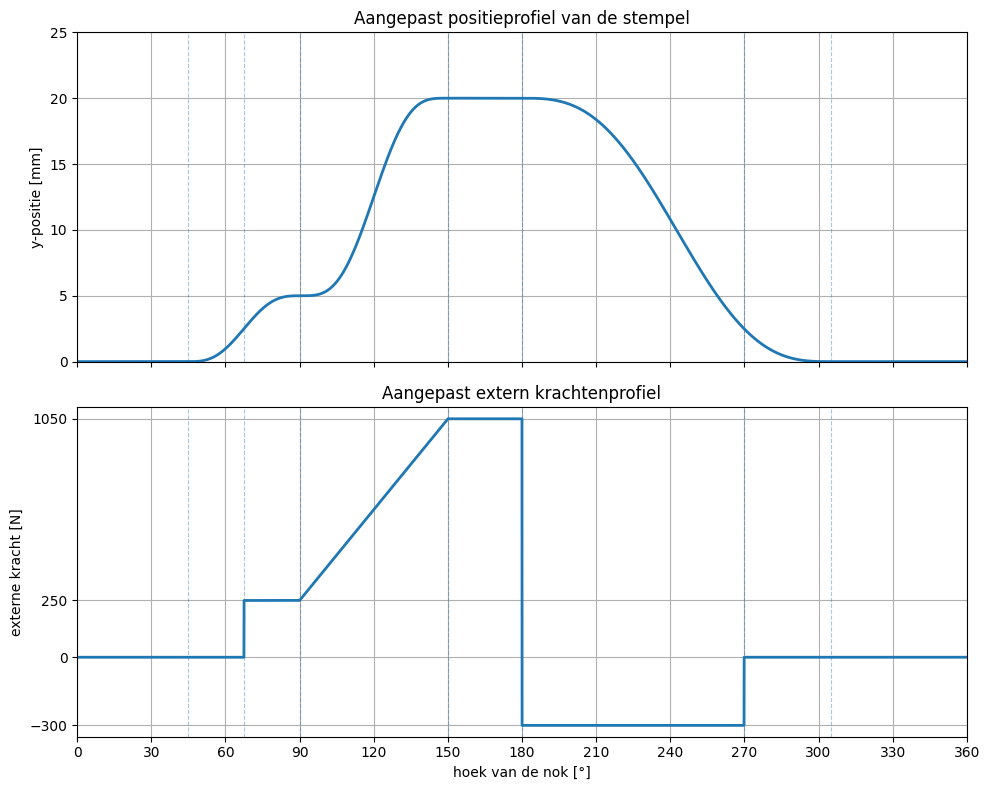

In [7]:
# vergelijkende grafieken: positie, kracht

fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
key_angles = [45, theta1, 90, 150, 180, theta2, 305]

# Positie
axs[0].plot(theta_deg, lift, linewidth=2)
axs[0].set_ylabel("y-positie [mm]")
axs[0].set_title("Aangepast positieprofiel van de stempel")
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].grid(True)

# Kracht
axs[1].plot(theta_deg, ext_load, linewidth=2)
axs[1].set_ylabel("externe kracht [N]")
axs[1].set_xlabel("hoek van de nok [°]")
axs[1].set_title("Aangepast extern krachtenprofiel")
axs[1].set_ylim(-350, 1100)
axs[1].set_yticks([-300, 0, 250, 1050])
axs[1].grid(True)

# Gemeenschappelijke x-as en verticale hulplijnen
for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 30))

    for angle in key_angles:
        ax.axvline(angle, linestyle="--", linewidth=0.8, alpha=0.4)

plt.tight_layout()
plt.show()

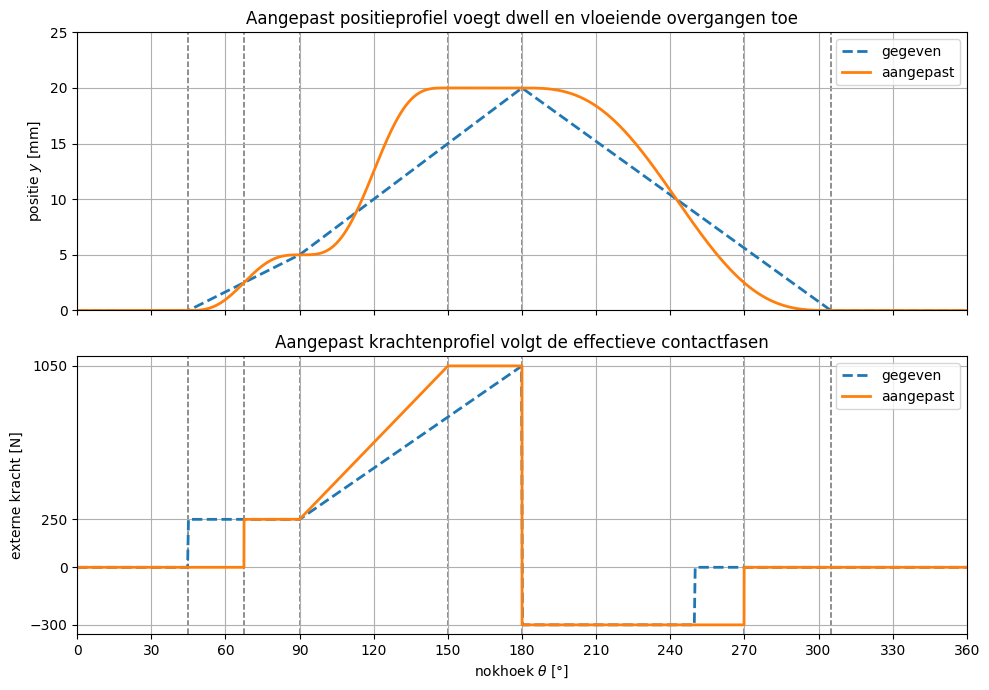

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
key_angles = [45, theta1, 90, 150, 180, theta2, 305]

axs[0].plot(theta_given_deg, lift_given, linewidth=2, linestyle="--", label="gegeven")
axs[0].plot(theta_deg, lift, linewidth=2, label="aangepast")
axs[0].set_ylabel("positie $y$ [mm]")
axs[0].set_title("Aangepast positieprofiel voegt dwell en vloeiende overgangen toe")
axs[0].set_ylim(0, 25)
axs[0].set_yticks(np.arange(0, 26, 5))
axs[0].legend()
axs[0].grid(True)

axs[1].plot(theta_given_deg, F, linewidth=2, linestyle="--", label="gegeven")
axs[1].plot(theta_deg, ext_load, linewidth=2, label="aangepast")
axs[1].set_ylabel("externe kracht [N]")
axs[1].set_xlabel("nokhoek $\\theta$ [°]")
axs[1].set_title("Aangepast krachtenprofiel volgt de effectieve contactfasen")
axs[1].set_ylim(-350, 1100)
axs[1].set_yticks([-300, 0, 250, 1050])
axs[1].legend()
axs[1].grid(True)

for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 30))
    for angle in key_angles:
        ax.axvline(angle, linestyle="--", linewidth=1.1, alpha=0.75, color="0.25", zorder=0)

plt.tight_layout()
plt.show()

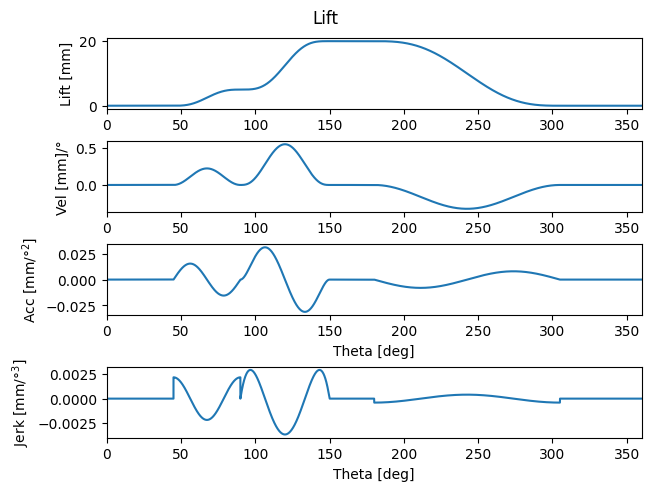

In [9]:
# Grafieken: positie, snelheid, versnelling, jerk

def plotMotionLaw(t,lift,vel,acc,jerk):
    fig1, ax1 = plt.subplots(nrows=4,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Vel [mm]/°")
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acc [mm/$°^2$]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

    ax1[3].plot(t, jerk)
    ax1[3].set_ylabel("Jerk [mm/$°^3$]")
    ax1[3].set_xlabel('Theta [deg]')
    ax1[3].set_xlim([0,360])

plotMotionLaw(theta_deg,lift,vel_deg,acc_deg, jerk_deg)
plt.show()

**Interpretatie grafieken:** Het aangepaste profiel bestaat uit een rustige intrede, een hoofdcompressie, een dwell op maximale lift en een gecontroleerde terugkeer. De positie, snelheid en versnelling blijven overal eindig en zijn continu op de segmentgrenzen. De jerk vertoont wel discontinuiteiten aan sommige overgangen tussen bewegingswetten. Dit is een gevolg van het stukgewijs opbouwen van het profiel. Voor dit eerste ontwerp is dat aanvaardbaar, omdat er geen sprongen optreden in positie of snelheid en de versnellingen beperkt blijven. Een nog vloeiender profiel zou mogelijk zijn door extra overgangssegmenten of hogere-orde polynomen te gebruiken, maar dat zou het ontwerp complexer maken.

## 1.4: Ontwerpdoelen
Uit de toepassing volgen de volgende ontwerpdoelen:

| Doel | Betekenis voor het ontwerp |
|---|---|
| Contact behouden | De normaalkracht tussen nok en volger moet positief blijven. |
| Drukhoek beperken | Een te grote drukhoek veroorzaakt grote zijdelingse krachten en meer wrijving. |
| Ondersnijding vermijden | De nokcontour moet geometrisch realiseerbaar blijven. |
| Wrijving beperken | De excentriciteit en geometrie worden gekozen om wrijvingsverlies te beperken. |
| Vermogenspieken beperken | Het ontwerp moet geen onnodig grote piekvermogens vragen. |

<a id="geometrie"></a>
# 2. Ontwerp van de nokgeometrie

## 2.1 Ontwerpaanpak

Voor het ontwerp van de nokgeometrie gebruiken we de Kloomok-Muffley-aanpak. In de onze implementatie is het opgesplitst in kleinere functies zodat berekening en visualisatie gescheiden blijven. Hierbij wordt eerst de grootte van de pitch radius $R_0$ gekozen op basis van de drukhoek. Daarna wordt gecontroleerd of de gekozen rolvolgerstraal $R_r$ geen ondersnijding veroorzaakt. Ten slotte wordt de effectieve nokcontour opgesteld.

De volgorde van het ontwerp is:

1. keuze van $R_0$ op basis van de maximale drukhoek;
2. keuze van $R_r$ op basis van ondersnijding;
3. bepaling van de basisstraal $R_b = R_0 - R_r$;
4. controle van drukhoek en kromtestraal over de volledige rotatie;
5. constructie van de nokcontour.

De excentriciteit wordt later gebruikt als optimalisatieparameter in de dynamische analyse met wrijving. In dit geometriegedeelte gebruiken we dus $e = 0$.

In [10]:
# Kloomok-Muffley hulpfuncties voor geometrieontwerp

alpha_limit = 35  # graden

geometry_segments = [
    ("Intrede", startangle2, endangle2, startlift2, endlift2, motionlaw2),
    ("Hoofdcompressie", startangle3, endangle3, startlift3, endlift3, motionlaw3),
    ("Terugkeer", startangle5, endangle5, startlift5, endlift5, motionlaw5),
]

def kloomok_segment_profile(startangle, endangle, startlift, endlift, motionlaw, n=1000):
    """
    maakt y, y', y'' voor segment
    """
    beta_deg = endangle - startangle # cam angle interval of the segment
    beta_rad = np.deg2rad(beta_deg)
    L = endlift - startlift

    u = np.linspace(0, 1, n)
    q, dq, ddq, dddq = motion_law(u, motionlaw)

    y = startlift + L * q
    dy_dtheta = L / beta_rad * dq
    d2y_dtheta2 = L / beta_rad**2 * ddq

    return u, y, dy_dtheta, d2y_dtheta2


def kloomok_pressure_angle_scan(startangle, endangle, startlift, endlift, motionlaw,
                                R0_values, eccentricity=0):
    """
    berekent max. drukhoek i.f.v. R0
    """
    _, y, dy_dtheta, _ = kloomok_segment_profile(
        startangle, endangle, startlift, endlift, motionlaw
    )

    alpha_max = []

    for R0_candidate in R0_values:
        d = np.sqrt(R0_candidate**2 - eccentricity**2)
        alpha = np.arctan((dy_dtheta - eccentricity) / (d + y))
        alpha_max.append(np.max(np.abs(np.rad2deg(alpha))))

    return np.array(alpha_max)


def kloomok_curvature_scan(startangle, endangle, startlift, endlift, motionlaw, R0_values):
    """
    berekent minimale kromtestraal i.f.v. R0
    """
    _, y, dy_dtheta, d2y_dtheta2 = kloomok_segment_profile(
        startangle, endangle, startlift, endlift, motionlaw
    )

    rho_min = []

    for R0_candidate in R0_values:
        R = R0_candidate + y

        rho = ((R**2 + dy_dtheta**2)**1.5) / (
            R**2 + 2*dy_dtheta**2 - R*d2y_dtheta2
        )

        rho = rho[np.isfinite(rho)]
        rho = rho[rho > 0]

        rho_min.append(np.min(rho) if len(rho) > 0 else np.nan)

    return np.array(rho_min)

"""
De formules komen uit de Kloomok-Muffley-methode. 
We hebben de functie opgesplitst zodat we drukhoek, 
ondersnijding en finale validatie apart kunnen tonen.
"""


'\nDe formules komen uit de Kloomok-Muffley-methode. \nWe hebben de functie opgesplitst zodat we drukhoek, \nondersnijding en finale validatie apart kunnen tonen.\n'

## 2.2 Pitch radius, rolvolgerstraal en basisstraal

De pitch radius $R_0$ is de afstand van het middelpunt van de nok tot het middelpunt van de volger bij nul lift. Omdat de rolvolger zelf een straal $R_r$ heeft, geldt:
$$
R_b = R_0 - R_r
$$
Een grotere $R_0$ verlaagt meestal de drukhoek en verkleint de kans op ondersnijding, maar maakt de nok groter. Een grotere rolvolger verlaagt de contactspanningen, maar vergroot de kans op ondersnijding omdat de effectieve nokcontour sterker afgerond moet worden.

In [11]:
R0 = 80       # mm, pitch radius
Rr = 35       # mm, rolvolgerstraal
base_radius = R0 - Rr
eccentricity_geometry = 0

print(f"Pitch radius R0:    {R0:.1f} mm")
print(f"Rolvolgerstraal Rr: {Rr:.1f} mm")
print(f"Basisstraal Rb:     {base_radius:.1f} mm")

Pitch radius R0:    80.0 mm
Rolvolgerstraal Rr: 35.0 mm
Basisstraal Rb:     45.0 mm


Voor het basisontwerp kiezen we $R_0 = 80$ mm en $R_r = 35$ mm. Daardoor wordt de basisstraal $R_b = 45$ mm. In de rest van dit deel controleren we of deze keuze voldoet voor drukhoek en ondersnijding.

## 2.3 Drukhoek

De drukhoek $\alpha$ bepaalt hoeveel zijdelingse kracht er op de volgergeleiding komt. Een te grote drukhoek verhoogt de wrijving en maakt de beweging minder efficiënt. Daarom gebruiken we als ontwerpvoorwaarde:
$$
|\alpha|_\text{max} < 35^\circ
$$
Met de Kloomok-Muffley-aanpak berekenen we voor elk bewegend segment hoe groot $R_0$ minstens moet zijn om onder deze limiet te blijven.

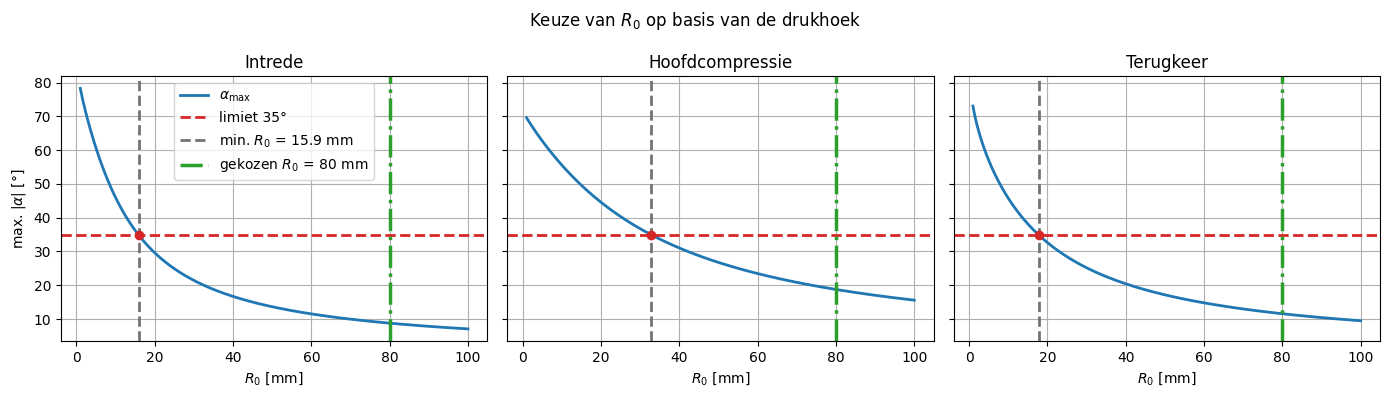

Intrede: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 15.9 mm
Hoofdcompressie: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 32.8 mm
Terugkeer: minimale R0 volgens drukhoekcriterium |alpha| < 35° = 17.8 mm


In [12]:
R0_scan_min = 1
R0_scan_max = 100 
R0_delta = 0.1 
R0_values = np.arange(R0_scan_min, R0_scan_max + R0_delta, R0_delta) 

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

required_R0 = {}

for ax, (name, startangle, endangle, startlift, endlift, motionlaw) in zip(axs, geometry_segments):
    alpha_max = kloomok_pressure_angle_scan(
        startangle, endangle, startlift, endlift, motionlaw,
        R0_values,
        eccentricity=eccentricity_geometry
    )

    ok = np.where(alpha_max <= alpha_limit)[0]
    R0_required = R0_values[ok[0]] if len(ok) > 0 else np.nan
    required_R0[name] = R0_required

    ax.plot(R0_values, alpha_max, linewidth=2, label=r"$\alpha_\mathrm{max}$")
    ax.axhline(alpha_limit, linestyle="--", linewidth=2, color="tab:red", label="limiet 35°")
    ax.axvline(R0_required, linestyle="--", linewidth=2, color="0.45", label=f"min. $R_0$ = {R0_required:.1f} mm")
    ax.axvline(R0, linestyle="-.", linewidth=2.5, color="tab:green", label=f"gekozen $R_0$ = {R0:.0f} mm")
    ax.scatter(R0_required, alpha_limit, color="tab:red", zorder=5)

    ax.set_title(name)
    ax.set_xlabel("$R_0$ [mm]")
    ax.grid(True)

axs[0].set_ylabel("max. $|\\alpha|$ [°]")
axs[0].legend()

plt.suptitle("Keuze van $R_0$ op basis van de drukhoek")
plt.tight_layout()
plt.show()

for name, R0_required in required_R0.items():
    print(f"{name}: minimale R0 volgens drukhoekcriterium |alpha| < 35° = {R0_required:.1f} mm")

Omwille van de 7e orde polynoom moeten we hier kiezen voor een maximale basis straal van 32.8mm. Praktisch wordt R0 = 35mm gekozen, zodat we toch een marge behouden op de drukhoek. Ook voor ondersnijding zal deze marge ten goede komen. De extra marge op de basisstraal zal ook voor een grotere inertie zorgen. In bestaande machines is de main compression roll het grootste element. De typscihe diameter range is: 60 - 120 mm. Als we onze steek straal kiezen binnen deze range zijn we nog beter af voor de drukhoek en blijven we ook in dezelfde grootte orders werken als de bestaande designs.

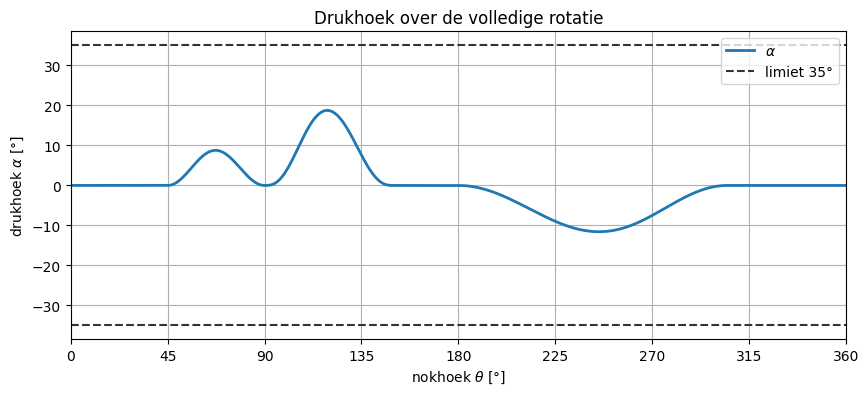

Maximale drukhoek: 18.76°


In [13]:
# Hier berekenen we de drukhoek over de volledige rotatie van de nok, met de gekozen R0 en zonder excentriciteit.

def calculate_pressure_angle(vel, eccentricity, R0, lift):
    d = np.sqrt(R0**2 - eccentricity**2)
    return np.arctan((vel - eccentricity) / (d + lift))

pressure_angle_geometry = calculate_pressure_angle(
    vel,
    eccentricity_geometry,
    R0,
    lift
)

plt.figure(figsize=(10, 4))
plt.plot(theta_deg, np.rad2deg(pressure_angle_geometry), linewidth=2, label="$\\alpha$")
plt.axhline(alpha_limit, linestyle="--", linewidth=1.5, color="0.2", label="limiet 35°")
plt.axhline(-alpha_limit, linestyle="--", linewidth=1.5, color="0.2")
plt.xlabel("nokhoek $\\theta$ [°]")
plt.ylabel("drukhoek $\\alpha$ [°]")
plt.title("Drukhoek over de volledige rotatie")
plt.xlim(0, 360)
plt.xticks(np.arange(0, 361, 45))
plt.grid(True)
plt.legend()
plt.show()

print(f"Maximale drukhoek: {np.max(np.abs(np.rad2deg(pressure_angle_geometry))):.2f}°")

## 2.4 Kromtestraal en ondersnijding

Na de keuze van $R_0$ controleren we de rolvolgerstraal $R_r$. Ondersnijding treedt op wanneer de rolvolger te groot is ten opzichte van de lokale kromtestraal van de pitch curve. Daarom moet gelden:

$$
\rho_{\text{pitch,min}} > R_r
$$

waarbij $\rho_{\text{pitch,min}}$ de minimale positieve kromtestraal van de pitch curve is:

$$ \rho =
 \frac{\left [ R^2 + (f'(\theta))^2 \right ]^{\frac{3}{2}}}
      {R^2 + 2(f'(\theta))^2 - R\, f''(\theta)},
\quad \text{met } R= R_0 +f(\theta).
$$

In [14]:
def kloomok_follower_radius_vs_beta(R0, target_beta, startlift, endlift, motionlaw, beta_values):
    """
    Berekent rho_pitch,min als functie van de segmenthoek beta.
    R0 blijft vast. Dit volgt de Kloomok-Muffley-controle voor ondersnijding.
    """
    rho_min_values = []

    for beta_deg in beta_values:
        beta_rad = np.deg2rad(beta_deg)
        L = endlift - startlift

        x = np.linspace(0, 1, 1000)
        y_norm, dy_norm, ddy_norm, _ = motion_law(x, motionlaw)

        y = startlift + L * y_norm
        dy_dtheta = L / beta_rad * dy_norm
        d2y_dtheta2 = L / beta_rad**2 * ddy_norm

        R = R0 + y
        numerator = (R**2 + dy_dtheta**2)**1.5
        denominator = R**2 + 2*dy_dtheta**2 - R*d2y_dtheta2

        with np.errstate(divide="ignore", invalid="ignore"):
            rho = numerator / denominator

        rho = rho[np.isfinite(rho)]
        rho = rho[rho > 0]

        rho_min_values.append(np.min(rho) if len(rho) > 0 else np.nan)

    rho_min_values = np.array(rho_min_values)

    rho_at_target = np.interp(target_beta, beta_values, rho_min_values)

    return rho_min_values, rho_at_target

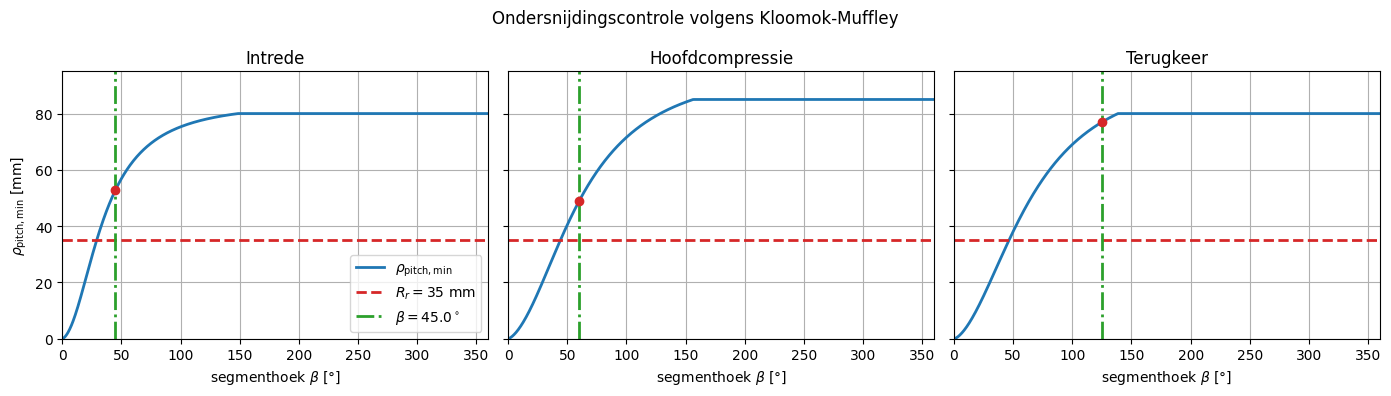

Intrede: rho_pitch,min bij gekozen beta = 52.83 mm
Hoofdcompressie: rho_pitch,min bij gekozen beta = 48.89 mm
Terugkeer: rho_pitch,min bij gekozen beta = 76.95 mm

Kleinste rho_pitch,min:          48.89 mm
Rolvolgerstraal Rr:              35.00 mm
Minimale effectieve kromtestraal: 13.89 mm


In [15]:
beta_values = np.linspace(1, 360, 1000)

curvature_segments = [
    ("Intrede", theta_seg2, startlift2, endlift2, motionlaw2),
    ("Hoofdcompressie", theta_seg3, startlift3, endlift3, motionlaw3),
    ("Terugkeer", theta_seg5, startlift5, endlift5, motionlaw5),
]

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

rho_at_design = {}

for ax, (name, beta_design, startlift, endlift, motionlaw) in zip(axs, curvature_segments):
    rho_min_values, rho_design = kloomok_follower_radius_vs_beta(
        R0,
        beta_design,
        startlift,
        endlift,
        motionlaw,
        beta_values
    )

    rho_at_design[name] = rho_design

    ax.plot(beta_values, rho_min_values, linewidth=2,
            label="$\\rho_{\\mathrm{pitch,min}}$")
    ax.axhline(Rr, linestyle="--", linewidth=2, color="tab:red",
               label=f"$R_r = {Rr:.0f}$ mm")
    ax.axvline(beta_design, linestyle="-.", linewidth=2, color="tab:green",
               label=f"$\\beta = {beta_design:.1f}^\\circ$")
    ax.scatter(beta_design, rho_design, color="tab:red", zorder=5)

    ax.set_title(name)
    ax.set_xlabel("segmenthoek $\\beta$ [°]")
    ax.set_xlim(0, max(360, beta_design + 30))
    ax.set_ylim(0, 95)
    ax.grid(True)

axs[0].set_ylabel("$\\rho_{\\mathrm{pitch,min}}$ [mm]")
axs[0].legend(loc="lower right")

plt.suptitle("Ondersnijdingscontrole volgens Kloomok-Muffley")
plt.tight_layout()
plt.show()

for name, rho_design in rho_at_design.items():
    print(f"{name}: rho_pitch,min bij gekozen beta = {rho_design:.2f} mm")

rho_min_global = min(rho_at_design.values())

print()
print(f"Kleinste rho_pitch,min:          {rho_min_global:.2f} mm")
print(f"Rolvolgerstraal Rr:              {Rr:.2f} mm")
print(f"Minimale effectieve kromtestraal: {rho_min_global - Rr:.2f} mm")

Voor alle bewegende segmenten ligt de minimale positieve kromtestraal van de pitch curve boven de gekozen rolvolgerstraal $R_r = 35$ mm. Daardoor wordt ondersnijding vermeden. De hoofdcompressie blijft het meest kritisch, omdat daar de kromming het sterkst varieert.

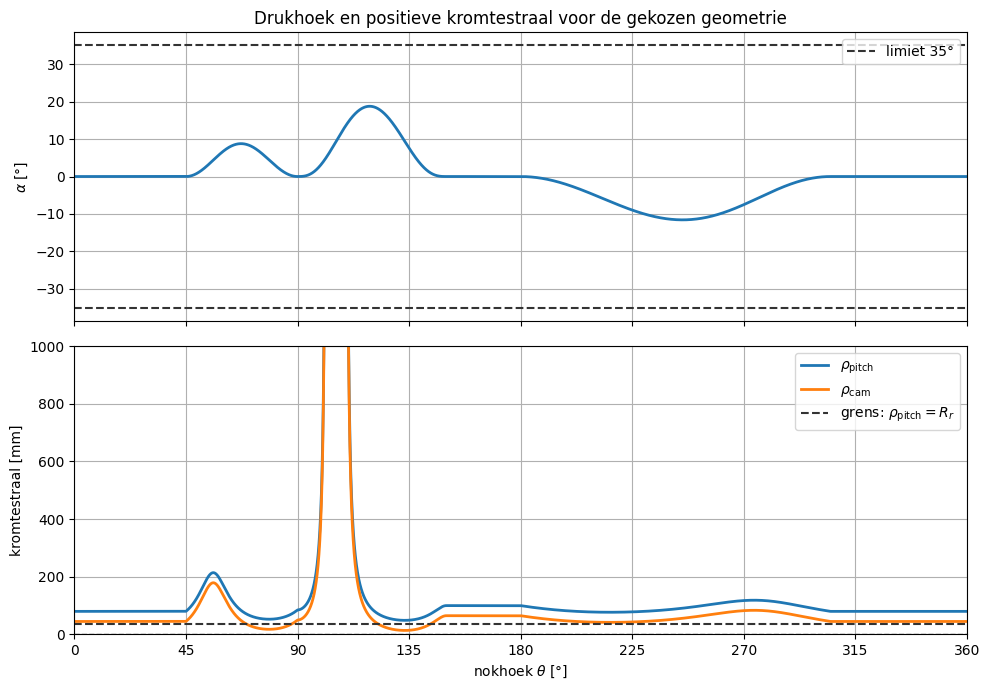

Minimale positieve rho_pitch: 48.89 mm
Minimale positieve rho_cam:   13.89 mm


In [16]:
def calculate_radius_curvature_pitch(R0, lift, vel, acc):
    R = R0 + lift
    numerator = (R**2 + vel**2)**1.5
    denominator = R**2 + 2*vel**2 - R*acc
    return numerator / denominator

rho_pitch_geometry = calculate_radius_curvature_pitch(R0, lift, vel, acc)
rho_cam_geometry = rho_pitch_geometry - Rr

# Enkel positieve en relevante waarden tonen
rho_pitch_plot = rho_pitch_geometry.copy()
rho_cam_plot = rho_cam_geometry.copy()

rho_pitch_plot[(rho_pitch_plot <= 0) | (rho_pitch_plot > 1000)] = np.nan
rho_cam_plot[(rho_cam_plot <= 0) | (rho_cam_plot > 1000)] = np.nan

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(theta_deg, np.rad2deg(pressure_angle_geometry), linewidth=2)
axs[0].axhline(alpha_limit, linestyle="--", linewidth=1.5, color="0.2", label="limiet 35°")
axs[0].axhline(-alpha_limit, linestyle="--", linewidth=1.5, color="0.2")
axs[0].set_ylabel("$\\alpha$ [°]")
axs[0].set_title("Drukhoek en positieve kromtestraal voor de gekozen geometrie")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(theta_deg, rho_pitch_plot, linewidth=2, label="$\\rho_\\mathrm{pitch}$")
axs[1].plot(theta_deg, rho_cam_plot, linewidth=2, label="$\\rho_\\mathrm{cam}$")
axs[1].axhline(Rr, linestyle="--", linewidth=1.5, color="0.2", label="grens: $\\rho_\\mathrm{pitch} = R_r$")
axs[1].axhline(0, linestyle="--", linewidth=1.0, color="0.4")
axs[1].set_xlabel("nokhoek $\\theta$ [°]")
axs[1].set_ylabel("kromtestraal [mm]")
axs[1].set_ylim(0, 1000)
axs[1].grid(True)
axs[1].legend()

for ax in axs:
    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 45))

plt.tight_layout()
plt.show()

print(f"Minimale positieve rho_pitch: {np.nanmin(rho_pitch_geometry[rho_pitch_geometry > 0]):.2f} mm")
print(f"Minimale positieve rho_cam:   {np.nanmin(rho_cam_geometry[rho_cam_geometry > 0]):.2f} mm")

Het asymptotisch gedrag van de kromtestraal komt doordat de pitch curve lokaal door een punt gaat waar de kromming zeer klein wordt of van teken verandert. De curve is daar lokaal bijna recht of gaat over van convex naar concaaf.

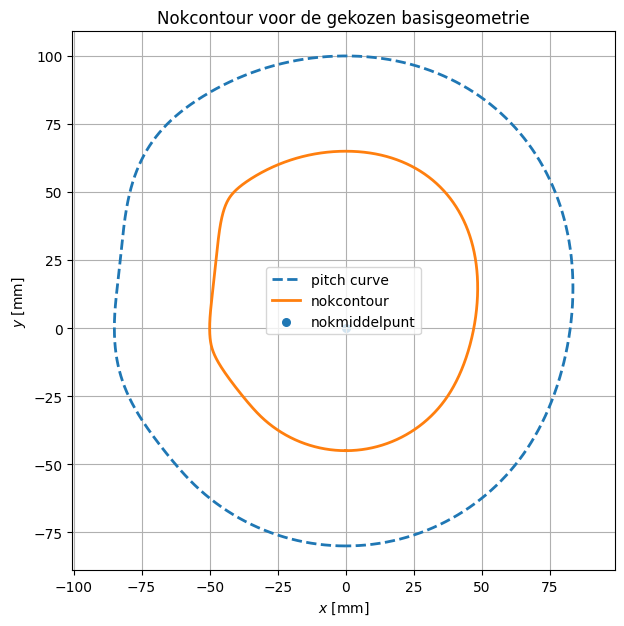

In [17]:
def plot_cam_contour(base_radius, follower_radius, eccentricity, theta, lift, pressure_angle):
    d = np.sqrt((base_radius + follower_radius)**2 - eccentricity**2)

    lambda_angle = -theta - np.arctan2(eccentricity, d + lift) + np.pi / 2

    x_pitch = -np.cos(lambda_angle) * np.sqrt((d + lift)**2 + eccentricity**2)
    y_pitch = -np.sin(lambda_angle) * np.sqrt((d + lift)**2 + eccentricity**2)

    x_cam = x_pitch - follower_radius * np.cos(-theta + pressure_angle + 3*np.pi/2)
    y_cam = y_pitch - follower_radius * np.sin(-theta + pressure_angle + 3*np.pi/2)

    plt.figure(figsize=(7, 7))
    plt.plot(x_pitch, y_pitch, linestyle="--", linewidth=2, label="pitch curve")
    plt.plot(x_cam, y_cam, linewidth=2, label="nokcontour")
    plt.scatter(0, 0, s=30, label="nokmiddelpunt")
    plt.xlabel("$x$ [mm]")
    plt.ylabel("$y$ [mm]")
    plt.title("Nokcontour voor de gekozen basisgeometrie")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_cam_contour(
    base_radius,
    Rr,
    eccentricity_geometry,
    theta,
    lift,
    pressure_angle_geometry
)

De figuur toont de pitch curve en de effectieve nokcontour voor de gekozen basisgeometrie. De pitch curve is de baan van het middelpunt van de rolvolger. De nokcontour ligt één rolvolgerstraal $R_r$ naar binnen. Omdat eerder gecontroleerd werd dat $\rho_{\text{pitch,min}} > R_r$, verwachten we geen ondersnijding.

In [18]:
# Dynamische basisparameters
mass = 15      # kg
rpm = 200      # rpm
omega = rpm * 2 * np.pi / 60

# Voor de eerste inverse dynamica gebruiken we de basisgeometrie zonder excentriciteit.
eccentricity_no_friction = 0
pressure_angle = pressure_angle_geometry

# dit is er gewoon omdat ik tussen documenten moest overzetten en namen anders waren...
def calculatePressureAngle(vel, exc, base_radius, follower_radius, lift):
    R0_local = base_radius + follower_radius
    return calculate_pressure_angle(vel, exc, R0_local, lift)

<a id="dynamica"></a>
# 3. Inverse dynamica en nokveer
## 3.1 Inverse dynamica zonder wrijving
Na het geometrisch ontwerp berekenen we welke normaalkracht nodig is om het voorgeschreven bewegingsprofiel te realiseren. Dit is inverse dynamica: de beweging is gekend, en daaruit volgen de krachten. In eerste instantie verwaarlozen we wrijving. De normaalkracht bestaat dan uit bijdragen van de externe belasting, de traagheidskracht, de zwaartekracht, de veer en de voorspanning. Deze analyse toont of de volger altijd contact houdt met de nok.

### Krachtevenwichten:
**Verticaal krachtevenwicht**:
$$
N\, \cos(\alpha) = F_{\text{func}} + F_v + m \frac{d^2y}{dt^2} + m\, g\, \cos(\gamma) + \mu R,
$$
met:
- $m$: de massa van het volger-lichaam.
- $\gamma$: hoek tussen de volgerbeweging en de vertikale.
- $\mu$: Coulomb-wrijvingsco&euml;fficient.
- $g$: zwaartekrachtversnelling.
- $y$: verplaatsing van de volger, positief in opwaartse richting.
- $\alpha$: drukhoek.

In sectie 3.1 nemen we $\mu = 0$, waardoor de wrijvingsterm wegvalt. De uitgebreide vorm wordt later opnieuw gebruikt wanneer wrijving expliciet wordt toegevoegd.

**Resulterende contactkracht**

Indien:
- de volger een perfect star lichaam is.
- de glijwrijving in de volger verwaarloosbaar is.
- de rotatiesnelheid van de nok constant is.
- er permanent contact is tussen nok en volger, d.w.z. $y(t) := S(t) = S(\theta/\omega)$.
Dan is de contact-normaalkracht $N$ tussen nok en volger
$$
N= \frac{F_{\text{func}} + F_{v0} + k_v S + m \omega^2 \frac{d^2 S(\theta)}{d\theta^2} - mg \, \cos(\gamma)}{\cos(\alpha)},
$$
met $k_v$ de veerconstante, en $F_{v0}$ de voorspanning in die veer, by $S=0$.

In [19]:
# Berekening van de krachten op de volger, inclusief veer, voorspanning, externe belasting, massa en versnelling.

def calculateForce(rpm, lift, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc):
    omega = rpm * 2 * np.pi / 60

    normalforce_spring = lift * spring_constant / np.cos(pressure_angle)
    preload_force = spring_preload / np.cos(pressure_angle)
    gravity_force = -mass * 9.81 / np.cos(pressure_angle)
    normalforce_load = ext_load / np.cos(pressure_angle)
    normalforce_acc = mass * acc / 1000 * omega**2 / np.cos(pressure_angle)

    normalforce_tot = (
        normalforce_spring
        + normalforce_load
        + normalforce_acc
        + gravity_force
        + preload_force
    )

    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return (
        normalforce_tot,
        normalforce_acc,
        normalforce_load,
        normalforce_spring,
        force_x,
        force_y,
        gravity_force,
        preload_force
    )

# Plotten van verschillende krachten
def plotForces(theta_deg, normalforce_tot, normalforce_acc, normalforce_load,
               normalforce_spring, force_x, force_y, gravity_force, preload_force):

    fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

    # Normaalkrachtbijdragen
    axs[0, 0].plot(theta_deg, normalforce_tot, linewidth=2, label="totaal")
    axs[0, 0].plot(theta_deg, normalforce_acc, "--", label="inertie")
    axs[0, 0].plot(theta_deg, normalforce_load, ":", label="externe belasting")
    axs[0, 0].plot(theta_deg, normalforce_spring, "-.", label="veer")
    axs[0, 0].plot(theta_deg, gravity_force, ":", label="zwaartekracht")
    axs[0, 0].plot(theta_deg, preload_force, ":", label="voorspanning")
    axs[0, 0].set_ylabel("normaalkracht [N]")
    axs[0, 0].set_title("Bijdragen tot de normaalkracht")
    axs[0, 0].legend(fontsize=8)
    axs[0, 0].grid(True)

    # Contactcontrole
    axs[0, 1].plot(theta_deg, normalforce_tot, linewidth=2)
    axs[0, 1].axhline(0, color="black", linewidth=1)
    axs[0, 1].fill_between(
        theta_deg, normalforce_tot, 0,
        where=(normalforce_tot < 0),
        alpha=0.25,
        label="contactverlies"
    )
    axs[0, 1].fill_between(
        theta_deg, normalforce_tot, 0,
        where=(normalforce_tot >= 0),
        alpha=0.15,
        label="contact behouden"
    )

    min_force = np.min(normalforce_tot)
    min_theta = theta_deg[np.argmin(normalforce_tot)]
    axs[0, 1].scatter(min_theta, min_force, zorder=5)
    axs[0, 1].annotate(
        f"min = {min_force:.2f} N",
        xy=(min_theta, min_force),
        xytext=(min_theta + 20, min_force),
        arrowprops=dict(arrowstyle="->"),
        fontsize=9
    )

    axs[0, 1].set_ylabel("normaalkracht [N]")
    axs[0, 1].set_title("Controle op contactverlies")
    axs[0, 1].legend(fontsize=8)
    axs[0, 1].grid(True)

    # Horizontale kracht
    axs[1, 0].plot(theta_deg, force_x, linewidth=2)
    axs[1, 0].set_ylabel("$F_x$ [N]")
    axs[1, 0].set_xlabel("nokhoek $\\theta$ [°]")
    axs[1, 0].set_title("Horizontale krachtcomponent")
    axs[1, 0].grid(True)

    # Verticale kracht
    axs[1, 1].plot(theta_deg, force_y, linewidth=2)
    axs[1, 1].set_ylabel("$F_y$ [N]")
    axs[1, 1].set_xlabel("nokhoek $\\theta$ [°]")
    axs[1, 1].set_title("Verticale krachtcomponent")
    axs[1, 1].grid(True)

    for ax in axs.flatten():
        ax.set_xlim(0, 360)

    plt.tight_layout()
    plt.show()

Zonder veer en zonder preload krijgen we de grafiek hieronder. Zonder veer en zonder voorspanning wordt de normaalkracht negatief tijdens een deel van de cyclus. Fysisch betekent dit dat de volger het contact met de nok zou verliezen. Een nokveer (preload) is dus nodig om contact te garanderen.

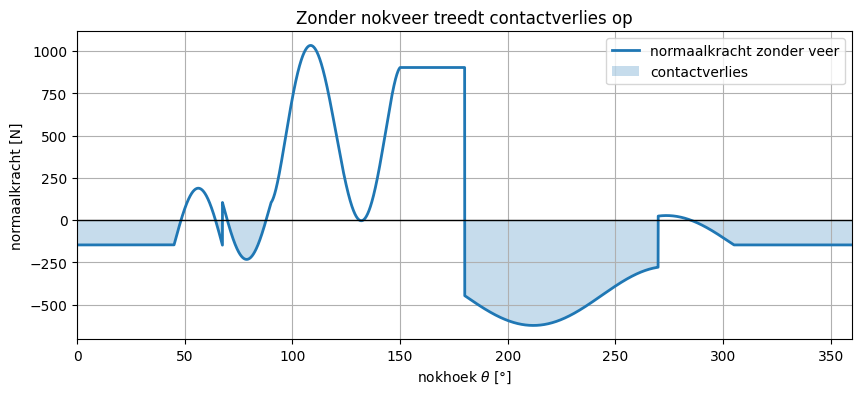

Minimale normaalkracht zonder veer: -623.66 N


In [20]:
spring_constant_zero = 0
spring_preload_zero = 0

(
    normalforce_tot1,
    normalforce_acc1,
    normalforce_load1,
    normalforce_spring1,
    force_x1,
    force_y1,
    gravity_force1,
    preload_force1
) = calculateForce(
    rpm,
    lift,
    spring_constant_zero,
    spring_preload_zero,
    pressure_angle,
    ext_load,
    mass,
    acc
)

plt.figure(figsize=(10, 4))
plt.plot(theta_deg, normalforce_tot1, linewidth=2, label="normaalkracht zonder veer")
plt.axhline(0, color="black", linewidth=1)

plt.fill_between(
    theta_deg,
    normalforce_tot1,
    0,
    where=(normalforce_tot1 < 0),
    alpha=0.25,
    label="contactverlies"
)

plt.xlabel("nokhoek $\\theta$ [°]")
plt.ylabel("normaalkracht [N]")
plt.title("Zonder nokveer treedt contactverlies op")
plt.xlim(0, 360)
plt.grid(True)
plt.legend()
plt.show()

print(f"Minimale normaalkracht zonder veer: {np.min(normalforce_tot1):.2f} N")

## 3.2 Ontwerp van preload en veerconstante
De preload is belangrijk om te zorgen dat de volger tegen de zwaartekracht terug naar de nok kan worden gebracht. Verder moet met een combinatie van de preload en de veerconstante ervoor gezorgd worden dat de volger altijd in contact is met de nok. Dit betekent dat de minimale resulterende normaalkracht groter dan of gelijk moet zijn aan 0N.

Meer preload:
- <span style="color:red">verhoogt de normaalkracht overal</span>
- <span style="color:red">verhoogt dus ook wrijving en motorkoppel overal</span>
- minstens 150N nodig om de zwaartekracht tegen te werken in de beweging terug naar de startpositie

Grotere veerconstante:
- <span style="color:red">geeft hoge normaalkracht bij maximale indrukking</span>
- <span style="color:red">verhoogt piekkracht en piekkoppel</span>

Omdat de zwaartekracht ons tegenwerkt, is de minimaal vereiste voorspanning: 
$$ N(\theta = 0) = \frac{F_{v0} - mg \, \cos(\gamma)}{\cos(\alpha)} > 0 \Leftrightarrow F_{v0} > mg \, \cos(\gamma) $$
Dit leidt tot de eerste voorwaarde. Verder kan er een afweging worden gemaakt om te zien of een stijve veer voldoende is om contact tijdens de beweging te garanderen. Een minimale voorspanning is nodig om de zwaartekracht tegen te gaan. 

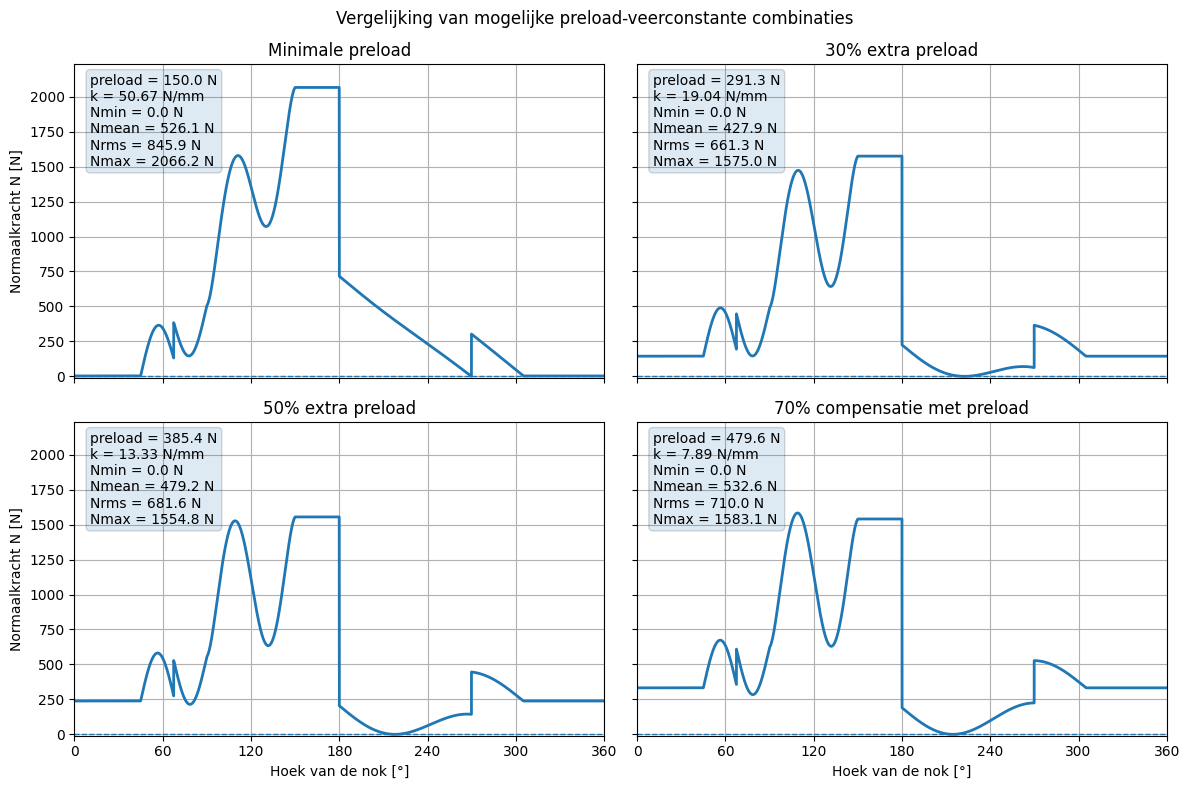

Gekozen veerontwerp
--------------------
Keuze:                 30% extra preload
spring_preload:        291.26 N
spring_constant:       19.04 N/mm
minimale normaalkracht: 0.00 N
gemiddelde normaalkracht: 427.88 N
piek-normaalkracht:    1574.99 N
rms-normaalkracht:     661.27 N

Referenties
-----------
Zonder preload/veer: minimale N = -623.66 N
Preload-only oplossing: preload = 620.87 N


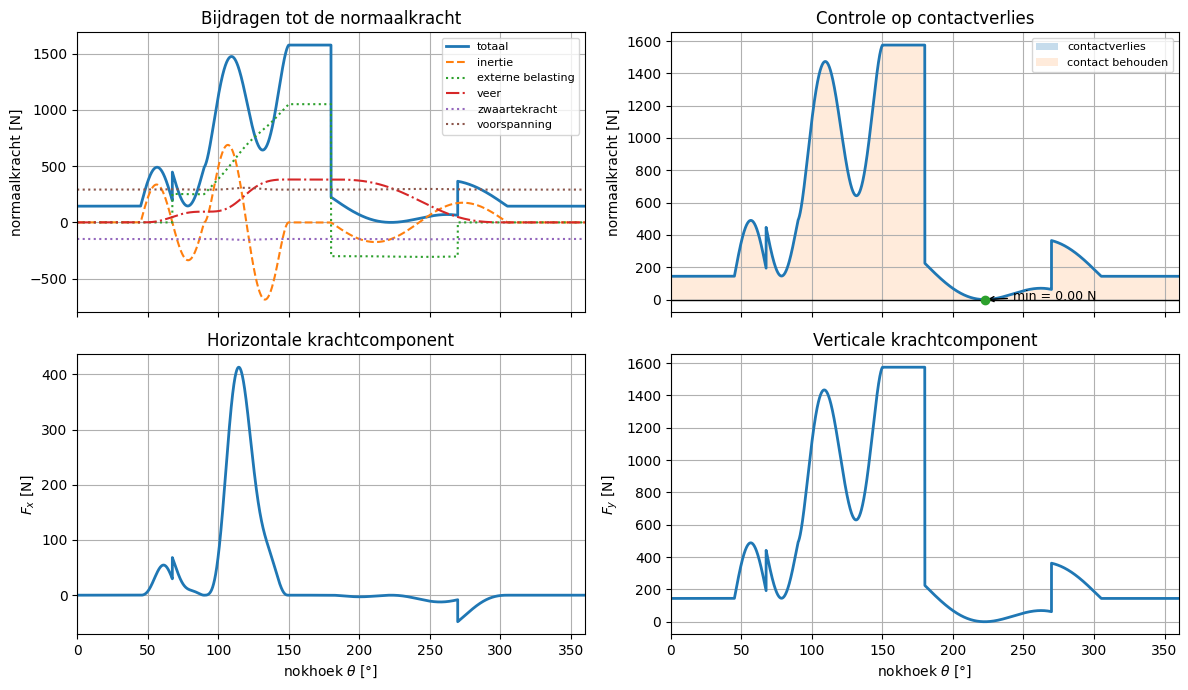

In [21]:
# Spring design: preload-stiffness trade-off

# Deze cel vervangt de oude manuele keuze van spring_preload en spring_constant.
# De rest van de notebook kan blijven werken omdat alle oude variabelen
# opnieuw worden aangemaakt: spring_constant, spring_preload,
# normalforce_tot, normalforce_tot1/2/3, force_x3, force_y3, ...

# Design constraints
preload_min = 10 * mass   # minimale preload
N_target = 0              # N, minimale toegelaten normaalkracht; 0 N = net geen loshechting
lift_eps = 1e-6           # mm, numerieke tolerantie om deling door nul bij lift = 0 te vermijden

omega = rpm * 2 * np.pi / 60
cos_alpha = np.cos(pressure_angle)

if np.any(cos_alpha <= 0):
    raise ValueError("De drukhoek is te groot: cos(alpha) wordt nul of negatief.")

# Krachtbijdrage in de teller van de normaalkracht zonder veer en zonder preload.
# De calculateForce-functie deelt deze teller achteraf door cos(alpha).
base_force_without_spring = (
    ext_load
    + mass * acc / 1000 * omega**2
    - mass * 9.81
)


def required_preload_for_k(k, N_target=0):
    """
    Berekent de minimale preload voor een gegeven veerconstante k,
    zodat N(theta) >= N_target over de volledige cyclus.
    """
    preload_required = N_target * cos_alpha - base_force_without_spring - k * lift
    return max(preload_min, np.max(preload_required))


def required_k_for_preload(preload, N_target=0):
    """
    Berekent de minimale veerconstante voor een gegeven preload,
    zodat N(theta) >= N_target over de volledige cyclus.

    Op punten waar lift = 0 kan de veerconstante niet helpen.
    Als daar de preload onvoldoende is, bestaat er geen eindige k-oplossing.
    """
    required_numerator = N_target * cos_alpha - base_force_without_spring - preload

    # Check punten waar de veer niet kan helpen omdat de lift nul is.
    mask_zero_lift = lift <= lift_eps
    if np.any(required_numerator[mask_zero_lift] > 1e-9):
        return np.inf

    # Voor punten met lift > 0 geldt: k >= required_numerator / lift
    mask_positive_lift = lift > lift_eps
    k_required_array = required_numerator[mask_positive_lift] / lift[mask_positive_lift]

    return max(0, np.max(k_required_array))


def evaluate_spring_case(label, preload):
    """
    Bepaalt voor één gekozen preload de minimale veerconstante,
    berekent de resulterende krachten en geeft samenvattende metrics terug.
    """
    k = required_k_for_preload(preload, N_target)

    if not np.isfinite(k):
        raise ValueError(
            f"Geen eindige veerconstante mogelijk voor '{label}'. "
            "De preload is onvoldoende op een punt waar lift = 0."
        )

    (
        normalforce_tot_case,
        normalforce_acc_case,
        normalforce_load_case,
        normalforce_spring_case,
        force_x_case,
        force_y_case,
        gravity_force_case,
        preload_force_case
    ) = calculateForce(
        rpm,
        lift,
        k,
        preload,
        pressure_angle,
        ext_load,
        mass,
        acc
    )

    return {
        "label": label,
        "preload": preload,
        "k": k,
        "normalforce_tot": normalforce_tot_case,
        "normalforce_acc": normalforce_acc_case,
        "normalforce_load": normalforce_load_case,
        "normalforce_spring": normalforce_spring_case,
        "force_x": force_x_case,
        "force_y": force_y_case,
        "gravity_force": gravity_force_case,
        "preload_force": preload_force_case,
        "N_min": np.min(normalforce_tot_case),
        "N_mean": np.mean(normalforce_tot_case),
        "N_rms": np.sqrt(np.mean(normalforce_tot_case**2)),
        "N_max": np.max(normalforce_tot_case),
    }


# ---------------------------------------------------------
# Referenties en voorbeeldontwerpen
# ---------------------------------------------------------

# Preload-only referentie: k = 0 en preload net groot genoeg om contact te behouden.
preload_only = required_preload_for_k(0, N_target)
(
    normalforce_tot2,
    normalforce_acc2,
    normalforce_load2,
    normalforce_spring2,
    force_x2,
    force_y2,
    gravity_force2,
    preload_force2
) = calculateForce(
    rpm,
    lift,
    0,
    preload_only,
    pressure_angle,
    ext_load,
    mass,
    acc
)

# Het verschil tussen de minimale preload en de preload-only oplossing
# wordt gebruikt om vier transparante ontwerpvoorbeelden te maken.
delta_preload = preload_only - preload_min

preload_fractions = [0.0, 0.3, 0.5, 0.7]
case_labels = [
    "Minimale preload",
    "30% extra preload",
    "50% extra preload",
    "70% compensatie met preload"
]

spring_design_cases = []
for label, fraction in zip(case_labels, preload_fractions):
    preload_case = preload_min + fraction * delta_preload
    spring_design_cases.append(evaluate_spring_case(label, preload_case))


# ---------------------------------------------------------
# Plot de vier voorbeeldontwerpen in één kader
# ---------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axs = axs.flatten()

N_global_max = max(case["N_max"] for case in spring_design_cases)
ymax = 1.08 * N_global_max

for ax, case in zip(axs, spring_design_cases):
    ax.plot(theta_deg, case["normalforce_tot"], linewidth=2)
    ax.axhline(N_target, linestyle="--", linewidth=1)
    ax.set_xlim(0, 360)
    ax.set_ylim(min(-10, 0.05 * ymax), ymax)
    ax.set_xticks(np.arange(0, 361, 60))
    ax.grid(True)

    info_text = (
        f"preload = {case['preload']:.1f} N\n"
        f"k = {case['k']:.2f} N/mm\n"
        f"Nmin = {case['N_min']:.1f} N\n"
        f"Nmean = {case['N_mean']:.1f} N\n"
        f"Nrms = {case['N_rms']:.1f} N\n"
        f"Nmax = {case['N_max']:.1f} N"
    )

    ax.text(
        0.03,
        0.97,
        info_text,
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    ax.set_title(case["label"])

for ax in axs[::2]:
    ax.set_ylabel("Normaalkracht N [N]")
for ax in axs[2:]:
    ax.set_xlabel("Hoek van de nok [°]")

fig.suptitle("Vergelijking van mogelijke preload-veerconstante combinaties")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Kies een transparant compromisontwerp
# ---------------------------------------------------------
# We kiezen hier bewust geen rigoureuze optimalisatie, maar een engineering compromis.
# Case 0 gebruikt minimale preload maar vereist de stijfste veer.
# Case 3 gebruikt meer preload en minder veerstijfheid, maar verhoogt de normaalkracht over de cyclus.
# Case 2 vormt een middenweg en wordt daarom verder gebruikt.

selected_case_index = 1   # 0=min preload, 1=30%, 2=50%, 3=70%
selected_case = spring_design_cases[selected_case_index]

spring_constant = selected_case["k"]
spring_preload = selected_case["preload"]

normalforce_tot = selected_case["normalforce_tot"]
normalforce_acc = selected_case["normalforce_acc"]
normalforce_load = selected_case["normalforce_load"]
normalforce_spring = selected_case["normalforce_spring"]
force_x = selected_case["force_x"]
force_y = selected_case["force_y"]
gravity_force = selected_case["gravity_force"]
preload_force = selected_case["preload_force"]

# Compatibiliteit met latere code uit het bestaande notebook.
# normalforce_tot3, force_x3 en force_y3 worden verder gebruikt als referentie
# voor de vergelijking met de geoptimaliseerde excentriciteit.
normalforce_tot3 = normalforce_tot
normalforce_acc3 = normalforce_acc
normalforce_load3 = normalforce_load
normalforce_spring3 = normalforce_spring
force_x3 = force_x
force_y3 = force_y
gravity_force3 = gravity_force
preload_force3 = preload_force

idx_min_force = np.argmin(normalforce_tot1)
displacement_at_min_force = lift[idx_min_force]

print("Gekozen veerontwerp")
print("--------------------")
print(f"Keuze:                 {selected_case['label']}")
print(f"spring_preload:        {spring_preload:.2f} N")
print(f"spring_constant:       {spring_constant:.2f} N/mm")
print(f"minimale normaalkracht: {np.min(normalforce_tot):.2f} N")
print(f"gemiddelde normaalkracht: {np.mean(normalforce_tot):.2f} N")
print(f"piek-normaalkracht:    {np.max(normalforce_tot):.2f} N")
print(f"rms-normaalkracht:     {np.sqrt(np.mean(normalforce_tot**2)):.2f} N")
print()
print("Referenties")
print("-----------")
print(f"Zonder preload/veer: minimale N = {np.min(normalforce_tot1):.2f} N")
print(f"Preload-only oplossing: preload = {preload_only:.2f} N")

# Detailplot van de gekozen oplossing met de bestaande plotfunctie.
plotForces(
    theta_deg,
    normalforce_tot,
    normalforce_acc,
    normalforce_load,
    normalforce_spring,
    force_x,
    force_y,
    gravity_force,
    preload_force
)


**Uitleg bij bovenste grafieken:** Hier kun je zien hoe we voor verschillende combinaties van preload en veerconstantes bepaalde belangrijke karakteristieken hebben berekend. Uit deze grafieken bleek dat 30% meer preload dan het minimum een goeie keuze was.

**Uitleg bij onderste grafieken:** Hier zie je de charakteristieken van de nok met de gekozen veerconstantes.

## 3.3: Referentie - excentriciteit zonder wrijving
In deze tussenstap optimaliseren we de excentriciteit nog zonder wrijving. Dit is niet de finale ontwerpkeuze, maar een referentieanalyse. Het criterium is hier de RMS-waarde van de normaalkracht, wat vooral iets zegt over de gemiddelde contactbelasting tussen nok en volger.

Later, wanneer wrijving wordt toegevoegd, gebruiken we een ander criterium: het wrijvingswerk over één cyclus. De optimale excentriciteit mag dan dus verschuiven.

Optimale excentriciteit zonder wrijving: (min RMS N): 7.00 mm
RMS-normaalkracht bij optimum:                        659.5 N


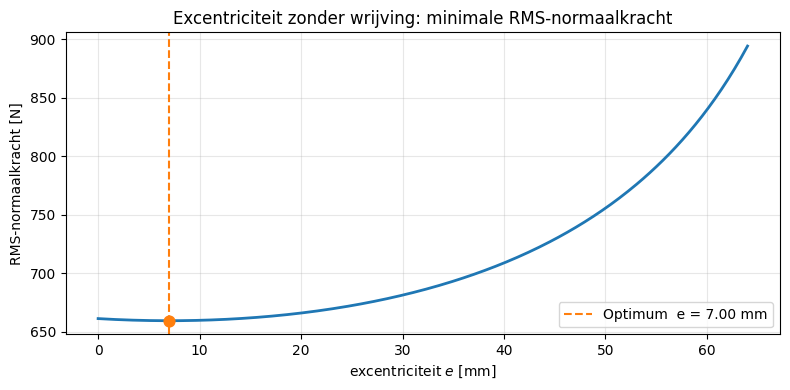

In [22]:
# Hier bepalen we de optimale excentriciteit voor de gekozen nok en veer, zonder wrijving.

from scipy.optimize import minimize_scalar
import matplotlib.colors as mcolors

omega = rpm * 2 * np.pi / 60

F_num = (ext_load
         + spring_preload
         + spring_constant * lift
         + mass * (omega**2) * acc / 1000   # acc is in mm/rad², convert to m/rad²
         - mass * 9.81)

def rms_normal_force(exc_val):
    pa = calculatePressureAngle(vel, exc_val, base_radius, Rr, lift)
    N  = F_num / np.cos(pa)
    return np.sqrt(np.trapezoid(N**2, theta) / (2 * np.pi))

res = minimize_scalar(rms_normal_force,
                      bounds=(0, 0.8 * (base_radius + Rr)),
                      method='bounded')

exc_optimal_rms = res.x
N_rms_optimal   = res.fun

print(f"Optimale excentriciteit zonder wrijving: (min RMS N): {exc_optimal_rms:.2f} mm")
print(f"RMS-normaalkracht bij optimum:                        {N_rms_optimal:.1f} N")

# --- Verification plot ---
exc_sweep = np.linspace(0, 0.8 * (base_radius + Rr), 300)
rms_sweep = np.array([rms_normal_force(e) for e in exc_sweep])

plt.figure(figsize=(8, 4))
plt.plot(exc_sweep, rms_sweep, color=list(mcolors.TABLEAU_COLORS.values())[0], lw=2)
plt.axvline(exc_optimal_rms, color=list(mcolors.TABLEAU_COLORS.values())[1],
            ls='--', lw=1.5, label=f'Optimum  e = {exc_optimal_rms:.2f} mm')
plt.scatter(exc_optimal_rms, N_rms_optimal,
            color=list(mcolors.TABLEAU_COLORS.values())[1], zorder=5, s=60)
plt.xlabel('excentriciteit $e$ [mm]')
plt.ylabel('RMS-normaalkracht [N]')
plt.title('Excentriciteit zonder wrijving: minimale RMS-normaalkracht')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretatie:** Zonder wrijving geeft de optimalisatie een excentriciteit die de RMS-normaalkracht verlaagt. Dit is nuttig als maat voor contactbelasting en slijtage, maar het is geen energieoptimum. Daarom gebruiken we deze waarde niet als finale ontwerpkeuze, maar als vergelijking met de optimalisatie met wrijving.

## 3.4 Inverse dynamica met wrijving

Bij het toevoegen van wrijving blijven het bewegingsprofiel, de externe belasting en het gekozen veerontwerp hetzelfde. Wat verandert, is de relatie tussen de gewenste kracht in de bewegingsrichting en de normaalkracht op de nok. De wrijvingskracht hangt af van de drukhoek, de normaalkracht en de bewegingsrichting. Daardoor kan dezelfde beweging een andere normaalkracht vereisen zodra wrijving wordt meegenomen.

In [23]:
def calculateForce_with_friction(rpm, lift, vel, spring_constant, spring_preload, pressure_angle, ext_load, mass, acc):
    mu = 0.1 # friction coefficient, assumed constant for simplicity
    omega = rpm*2*np.pi/60
    F_num = lift*spring_constant + spring_preload +  ext_load - mass*9.81 + mass*acc/1000*(omega**2)
    normalforce_tot = F_num / (np.cos(pressure_angle) - mu * np.abs(np.sin(pressure_angle))*np.sign(vel))
    friction_force = mu*np.abs(normalforce_tot*np.sin(pressure_angle))*np.sign(vel)
    force_x = normalforce_tot * np.sin(pressure_angle)
    force_y = normalforce_tot * np.cos(pressure_angle)

    return normalforce_tot, force_x,force_y, friction_force

In [24]:
def plotForces_with_friction(theta_deg, normalforce_tot, force_x, force_y, friction_force):

    fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

    axs[0, 0].plot(theta_deg, normalforce_tot, linewidth=2)
    axs[0, 0].axhline(0, color="black", linewidth=1)
    axs[0, 0].fill_between(
        theta_deg, normalforce_tot, 0,
        where=(normalforce_tot < 0),
        alpha=0.25,
        label="contactverlies"
    )
    axs[0, 0].fill_between(
        theta_deg, normalforce_tot, 0,
        where=(normalforce_tot >= 0),
        alpha=0.15,
        label="contact behouden"
    )
    axs[0, 0].set_ylabel("normaalkracht [N]")
    axs[0, 0].set_title("Normaalkracht met wrijving")
    axs[0, 0].legend(fontsize=8)
    axs[0, 0].grid(True)

    axs[0, 1].plot(theta_deg, friction_force, linewidth=2)
    axs[0, 1].axhline(0, color="black", linewidth=1)
    axs[0, 1].set_ylabel("wrijvingskracht [N]")
    axs[0, 1].set_title("Wrijvingskracht")
    axs[0, 1].grid(True)

    axs[1, 0].plot(theta_deg, force_x, linewidth=2)
    axs[1, 0].set_ylabel("$F_x$ [N]")
    axs[1, 0].set_xlabel("nokhoek $\\theta$ [°]")
    axs[1, 0].set_title("Horizontale krachtcomponent")
    axs[1, 0].grid(True)

    axs[1, 1].plot(theta_deg, force_y, linewidth=2)
    axs[1, 1].set_ylabel("$F_y$ [N]")
    axs[1, 1].set_xlabel("nokhoek $\\theta$ [°]")
    axs[1, 1].set_title("Verticale krachtcomponent")
    axs[1, 1].grid(True)

    for ax in axs.flatten():
        ax.set_xlim(0, 360)

    plt.tight_layout()
    plt.show()

# 3.5 Excentriciteit met wrijving

Excentriciteit beïnvloedt de drukhoek over het volledige nokprofiel. Daardoor verandert ook de zijdelingse kracht op de volger en dus de wrijvingskracht in de geleiding. Met wrijving is het daarom niet voldoende om alleen de RMS-normaalkracht te minimaliseren.

Het wrijvingswerk wordt berekend als:

$$
W_{\text{wrijving}}(e)
=
\int_{0}^{2\pi}
\left|F_{\text{wrijving}}(\theta,e)\right|
\left|\frac{dS}{d\theta}\right|
\, d\theta
$$

$F_{\text{wrijving}}$ wordt berekend uit het inverse-dynamicamodel met wrijving. De optimalisatie gebeurt onder twee voorwaarden: de drukhoek moet kleiner blijven dan $35^\circ$ en de normaalkracht moet positief blijven zodat contact behouden wordt.

We kiezen het wrijvingswerk als optimalisatiecriterium voor de excentriciteit, omdat wrijving een verlies is. Het totale vermogen bevat ook nuttige compressiearbeid en tijdelijke energieopslag in veer en inertie. Daarom is het totale gesigneerde gemiddelde vermogen minder geschikt als rechtstreeks optimalisatiecriterium.

Om te vermijden dat de wrijvingsoptimalisatie een ongunstig totaalontwerp oplevert, controleren we later wel het ogenblikkelijk vermogen, het piekvermogen, het koppel en de positieve energie per cyclus. Zo blijft de excentriciteit een compromis tussen wrijvingsverlies en motorbelasting.

In [25]:
critical_mask = (theta_deg >= 45) & (theta_deg <= 180)
return_mask = (theta_deg >= 180) & (theta_deg <= 305)

def friction_work(exc_val):
    pa = calculatePressureAngle(vel, exc_val, base_radius, Rr, lift)

    normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
        rpm,
        lift,
        vel,
        spring_constant,
        spring_preload,
        pa,
        ext_load,
        mass,
        acc
    )

    # Contact mag niet verloren gaan
    if np.min(normalforce_tmp) < 0:
        return 1e12 + 1e9 * abs(np.min(normalforce_tmp))

    # Drukhoek moet onder 35 graden blijven
    if np.max(np.abs(pa)) > np.deg2rad(35):
        return 1e12 + 1e9 * (np.max(np.abs(pa)) - np.deg2rad(35))**2

    # Frictiewerk ~ integraal van |F_friction| * |dy/dtheta| dtheta
    integrand = np.abs(friction_force_tmp) * np.abs(vel)
    return np.trapezoid(integrand, theta)

e_max = 0.8 * R0

result_friction = minimize_scalar(
    friction_work,
    bounds=(0.0, e_max),
    method="bounded"
)

exc_optimal_friction = result_friction.x
pressure_angle_opt = calculatePressureAngle(vel, exc_optimal_friction, base_radius, Rr, lift)

normalforce_tot_opt, force_x_opt, force_y_opt, friction_force_opt = calculateForce_with_friction(
    rpm,
    lift,
    vel,
    spring_constant,
    spring_preload,
    pressure_angle_opt,
    ext_load,
    mass,
    acc
)

print(f"Optimale excentriciteit met wrijving: {exc_optimal_friction:.2f} mm")
print(f"Wrijvingswerk bij optimum:            {result_friction.fun:.2f} Nmm")
print(f"Max α compressie 45–180°:             {np.max(np.abs(pressure_angle_opt[critical_mask]))*180/np.pi:.1f}°")
print(f"Max α terugkeer 180–305°:             {np.max(np.abs(pressure_angle_opt[return_mask]))*180/np.pi:.1f}°")
print(f"Minimale normaalkracht:               {np.min(normalforce_tot_opt):.2f} N")

# Compatibiliteit met latere oude code
exc_optimal = exc_optimal_friction
normalforce_tot_opt = normalforce_tot_opt

Optimale excentriciteit met wrijving: 22.77 mm
Wrijvingswerk bij optimum:            202.65 Nmm
Max α compressie 45–180°:             16.5°
Max α terugkeer 180–305°:             25.6°
Minimale normaalkracht:               0.00 N


Hierboven zijn de numerieke uitkomsten van de optimalisatie. Hieronder is een grafische voorstelling van een aantal andere waarden + het optimum.

In [26]:
def plot_friction_integrand_sweep(
        theta, theta_deg, vel, lift, acc,
        base_radius, Rr,
        ext_load, spring_preload, spring_constant,
        mass, rpm,
        exc_values=None,
        exc_optimal=None):

    R0_local = base_radius + Rr

    if exc_values is None:
        exc_values = np.round(np.linspace(0, 0.6 * R0_local, 7), 1)

    exc_fine = np.linspace(0, 0.75 * R0_local, 300)
    J_fine = np.zeros_like(exc_fine)

    for i, e in enumerate(exc_fine):
        pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

        normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
            rpm, lift, vel,
            spring_constant, spring_preload,
            pa, ext_load, mass, acc
        )

        integrand = np.abs(friction_force_tmp) * np.abs(vel)
        J_fine[i] = np.trapezoid(integrand, theta)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={"height_ratios": [2, 1]}
    )

    fig.suptitle("Wrijvingswerk voor verschillende excentriciteiten",
                 fontsize=13, fontweight="bold")

    colors = list(mcolors.TABLEAU_COLORS.values())[:len(exc_values)]

    for e, color in zip(exc_values, colors):
        pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

        normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
            rpm, lift, vel,
            spring_constant, spring_preload,
            pa, ext_load, mass, acc
        )

        integrand = np.abs(friction_force_tmp) * np.abs(vel)
        J_val = np.trapezoid(integrand, theta)

        ax_top.plot(theta_deg, integrand,
                    color=color, linewidth=1.6,
                    label=f"$e$ = {e:.1f} mm  ($J$ = {J_val:.0f})")
        ax_top.fill_between(theta_deg, integrand, alpha=0.06, color=color)

    for boundary, label in zip(
        [45, 90, 180, 305],
        ["45°", "90°", "180°", "305°"]
    ):
        ax_top.axvline(boundary, color="grey", linewidth=0.8, linestyle="--", alpha=0.6)
        ax_top.text(boundary + 1, ax_top.get_ylim()[1] * 0.95,
                    label, fontsize=8, color="grey", va="top")

    ax_top.set_xlabel("nokhoek $\\theta$ [°]")
    ax_top.set_ylabel("wrijvingswerkdichtheid [Nmm/rad]")
    ax_top.set_xlim(0, 360)
    ax_top.set_ylim(bottom=0)
    ax_top.legend(fontsize=8, loc="upper right")
    ax_top.grid(True, alpha=0.3)
    ax_top.set_title("Integrand per nokhoek — oppervlakte onder de curve is $J(e)$")

    ax_bot.plot(exc_fine, J_fine, linewidth=2, label="$J(e)$")
    ax_bot.fill_between(exc_fine, J_fine, alpha=0.15)

    for e, color in zip(exc_values, colors):
        pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

        normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
            rpm, lift, vel,
            spring_constant, spring_preload,
            pa, ext_load, mass, acc
        )

        integrand = np.abs(friction_force_tmp) * np.abs(vel)
        J_dot = np.trapezoid(integrand, theta)
        ax_bot.scatter(e, J_dot, color=color, zorder=5, s=50)

    if exc_optimal is not None:
        J_opt = friction_work(exc_optimal)
        ax_bot.scatter(exc_optimal, J_opt,
                       color="red", zorder=6, s=90, marker="*",
                       label=f"optimum $e$ = {exc_optimal:.2f} mm")
        ax_bot.axvline(exc_optimal, color="red", linestyle=":", linewidth=1.2)

    ax_bot.set_xlabel("excentriciteit $e$ [mm]")
    ax_bot.set_ylabel("$J(e)$ [Nmm]")
    ax_bot.grid(True, alpha=0.3)
    ax_bot.legend(fontsize=8)
    ax_bot.set_title("Totaal wrijvingswerk — minimum bepaalt de optimale excentriciteit")

    plt.tight_layout()
    plt.show()

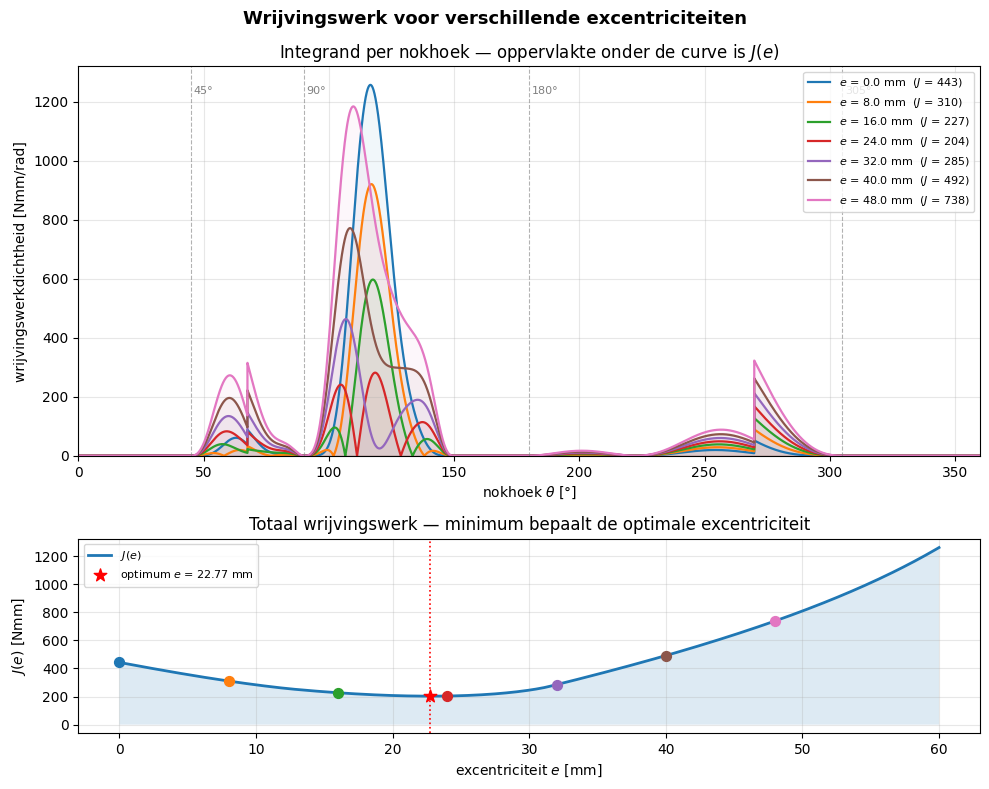

In [27]:
plot_friction_integrand_sweep(
    theta,
    theta_deg,
    vel,
    lift,
    acc,
    base_radius,
    Rr,
    ext_load,
    spring_preload,
    spring_constant,
    mass,
    rpm,
    exc_optimal=exc_optimal_friction
)

Hieronder tonen we de bijdrage aan wrijvingswerk tijdens compressie en terugkeer apart.

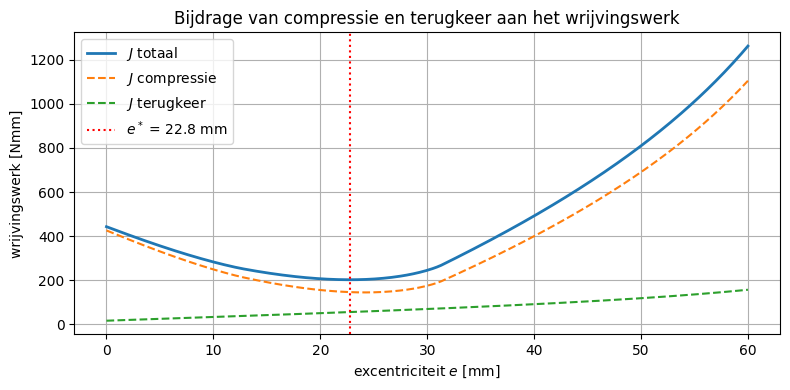

In [28]:
rise_mask = (theta_deg >= 45) & (theta_deg <= 180)
return_mask = (theta_deg >= 180) & (theta_deg <= 305)

exc_fine = np.linspace(0, 0.75 * R0, 300)

J_rise = np.zeros_like(exc_fine)
J_return = np.zeros_like(exc_fine)

for i, e in enumerate(exc_fine):
    pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

    normalforce_tmp, force_x_tmp, force_y_tmp, friction_force_tmp = calculateForce_with_friction(
        rpm, lift, vel,
        spring_constant, spring_preload,
        pa, ext_load, mass, acc
    )

    integrand = np.abs(friction_force_tmp) * np.abs(vel)

    J_rise[i] = np.trapezoid(integrand[rise_mask], theta[rise_mask])
    J_return[i] = np.trapezoid(integrand[return_mask], theta[return_mask])

plt.figure(figsize=(8, 4))
plt.plot(exc_fine, J_rise + J_return, linewidth=2, label="$J$ totaal")
plt.plot(exc_fine, J_rise, linestyle="--", linewidth=1.5, label="$J$ compressie")
plt.plot(exc_fine, J_return, linestyle="--", linewidth=1.5, label="$J$ terugkeer")
plt.axvline(exc_optimal_friction, color="red", linestyle=":",
            label=f"$e^*$ = {exc_optimal_friction:.1f} mm")

plt.xlabel("excentriciteit $e$ [mm]")
plt.ylabel("wrijvingswerk [Nmm]")
plt.title("Bijdrage van compressie en terugkeer aan het wrijvingswerk")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretatie**: De compressiefase levert de grootste bijdrage aan het wrijvingswerk, omdat daar de externe kracht het grootst is. De terugkeer levert minder absolute wrijving op, maar de drukhoek kan daar sterker veranderen door excentriciteit. Het optimum ontstaat dus vooral doordat excentriciteit de drukhoek tijdens de compressie gunstiger maakt, terwijl een te grote excentriciteit de wrijving in andere delen van de cyclus opnieuw verhoogt.

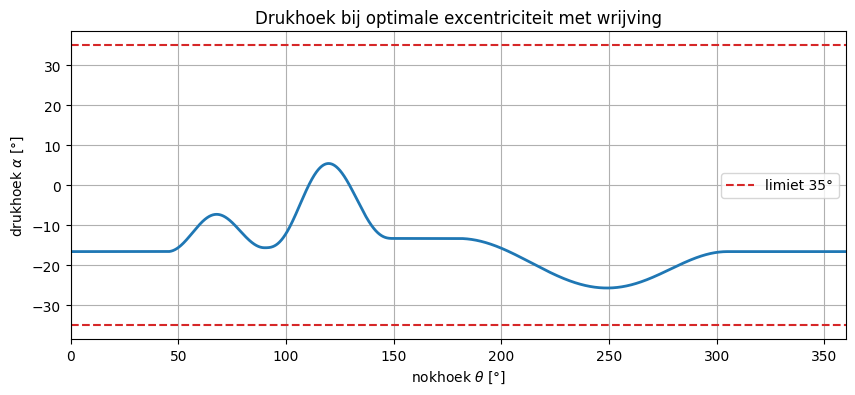

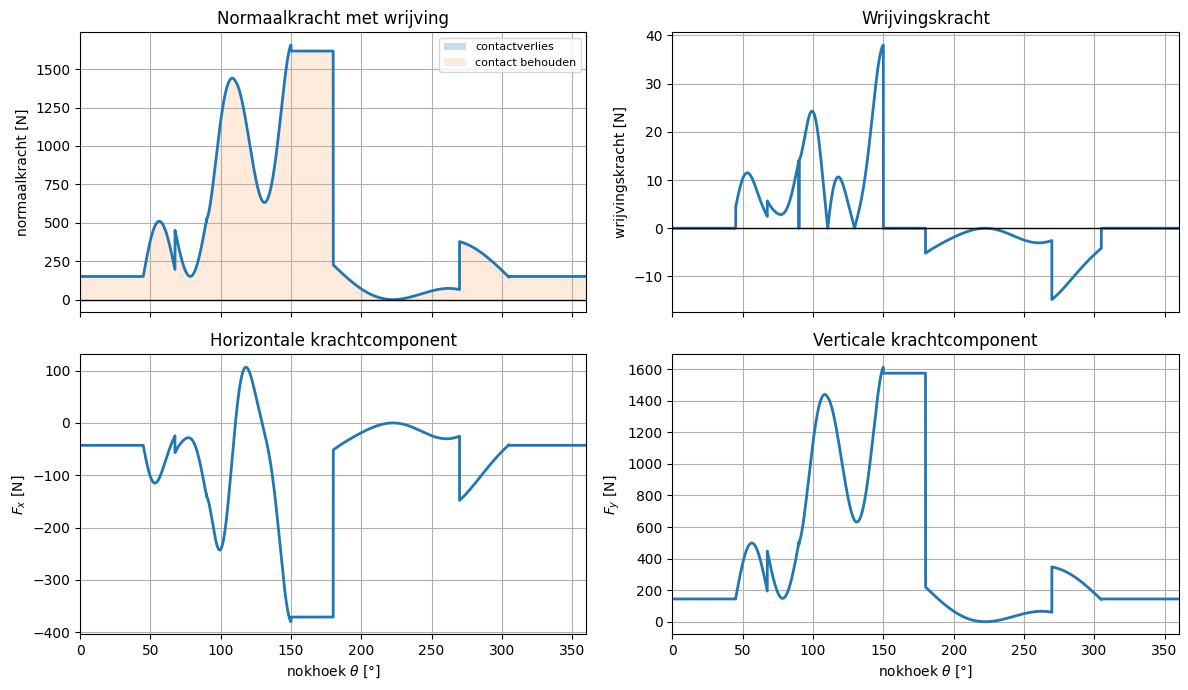

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(theta_deg, np.rad2deg(pressure_angle_opt), linewidth=2)
plt.axhline(35, linestyle="--", color="tab:red", linewidth=1.5, label="limiet 35°")
plt.axhline(-35, linestyle="--", color="tab:red", linewidth=1.5)
plt.xlabel("nokhoek $\\theta$ [°]")
plt.ylabel("drukhoek $\\alpha$ [°]")
plt.title("Drukhoek bij optimale excentriciteit met wrijving")
plt.xlim(0, 360)
plt.grid(True)
plt.legend()
plt.show()

plotForces_with_friction(
    theta_deg,
    normalforce_tot_opt,
    force_x_opt,
    force_y_opt,
    friction_force_opt
)

**Interpretatie:** De optimale excentriciteit met wrijving verschilt van de optimale excentriciteit zonder wrijving, omdat het optimalisatiecriterium anders is. Zonder wrijving minimaliseerden we de RMS-normaalkracht, dus de gemiddelde contactbelasting. Met wrijving minimaliseren we het wrijvingswerk. Een grotere excentriciteit kan de drukhoek gunstiger verdelen over compressie en terugkeer, waardoor de wrijvingsverliezen dalen.

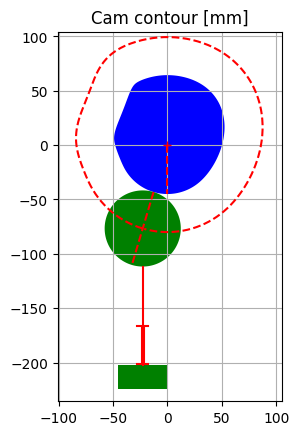

In [30]:
def plotCamContour(base_radius, follower_radius, exc, theta, lift, pressure_angle, dtheta):
    d = np.sqrt((base_radius + follower_radius)**2 - exc**2)
    lambda_ = -theta - np.arctan2(exc, d + lift) + np.pi / 2
    xpitch =  - np.cos(lambda_) * np.sqrt((d + lift)**2 + exc**2)
    ypitch = -np.sin(lambda_) * np.sqrt((d + lift)**2 + exc**2)  # negated

    xcam = xpitch - follower_radius * np.cos(-theta + pressure_angle + 3 * np.pi / 2)
    ycam = ypitch - follower_radius * np.sin(-theta + pressure_angle + 3 * np.pi / 2)  # negated

    pitch_curve = np.array([xpitch, ypitch])
    cam_curve   = np.array([xcam,   ycam])

    x_rolfol_center = -exc
    y_rolfol_center = -(d + lift[0])                              # negated: follower below cam
    x_rolfol = follower_radius * np.cos(theta) + x_rolfol_center
    y_rolfol = follower_radius * np.sin(theta) + y_rolfol_center

    min_distance_center_roller_to_bore = 2 * follower_radius
    height_bore = follower_radius
    width_block_on_follower  = base_radius / 2
    height_block_on_follower = base_radius / 2

    x_boreleft  = np.array([-exc - 5, -exc - 1, -exc - 1, -exc - 5])
    x_boreright = np.array([-exc + 5, -exc + 1, -exc + 1, -exc + 5])

    # bore is now below
    y_bore_top    = -(d + max(lift) + min_distance_center_roller_to_bore)
    y_bore_bottom = -(d + max(lift) + min_distance_center_roller_to_bore + height_bore)
    y_bore = np.array([y_bore_top, y_bore_top, y_bore_bottom, y_bore_bottom])

    length_follower = abs(y_bore_bottom) - (d + lift[0]) - follower_radius + 0.2

    # stem goes downward
    x_follower = np.array([x_rolfol_center, x_rolfol_center])
    y_follower = np.array([y_rolfol_center - follower_radius,
                            y_rolfol_center - follower_radius - length_follower])

    # block hangs below stem
    x_block_on_follower = np.array([-width_block_on_follower,  width_block_on_follower,
                                     width_block_on_follower, -width_block_on_follower]) + x_follower[0]
    y_block_on_follower = np.array([0, 0, -height_block_on_follower, -height_block_on_follower]) + y_follower[1]

    ref_line = np.array([[0, 0], [0, -base_radius]])              # reference line points downward

    # pressure angle line flipped
    x_pressangle = np.array([x_rolfol_center -  follower_radius * np.sin(pressure_angle[0]),
                              x_rolfol_center + follower_radius * np.sin(pressure_angle[0])])
    y_pressangle = np.array([y_rolfol_center + follower_radius * np.cos(pressure_angle[0]),
                               y_rolfol_center - follower_radius * np.cos(pressure_angle[0])])

    plt.figure()
    plt.fill(cam_curve[0, ::int(1 / dtheta)], cam_curve[1, ::int(1 / dtheta)], 'b')
    plt.fill(x_rolfol[::int(1 / dtheta)],     y_rolfol[::int(1 / dtheta)],     'g')
    plt.plot(pitch_curve[0, ::int(1 / dtheta)], pitch_curve[1, ::int(1 / dtheta)], '--r')
    plt.plot(0, 0, 'r+')
    plt.plot(x_pressangle, y_pressangle, 'r--')
    plt.plot(ref_line[0, :], ref_line[1, :], 'r--')
    plt.plot(x_boreleft,  y_bore, 'r')
    plt.plot(x_boreright, y_bore, 'r')
    plt.plot(x_follower,  y_follower, 'r')
    plt.fill(x_block_on_follower, y_block_on_follower, 'g')

    xlimits = [min(pitch_curve[0, :]), max(pitch_curve[0, :])]
    ylimits = [y_follower[1] - height_block_on_follower, max(pitch_curve[1, :])]

    plt.xlim(np.array(xlimits) * 1.2)
    plt.ylim([ylimits[0] * 1.05, ylimits[1] * 1.05])
    plt.gca().set_aspect('equal')
    plt.grid(True)
    plt.title('Cam contour [mm]')

plotCamContour(base_radius,Rr,exc_optimal_friction,theta,lift,pressure_angle_opt,dtheta)

**Interpretatie:** Deze nokcontour gebruikt de excentriciteit die werd gekozen op basis van het wrijvingswerk. Dit is dus de definitieve contour voor het nokontwerp. De eerder getoonde contour zonder excentriciteit was enkel de basisgeometrie voor de drukhoek- en ondersnijdingscontrole.

<a id="verificatie"></a>
# 4. Prestaties en verificatie

## 4.1 Vermogen, koppel en energie per cyclus

Na de keuze van de geometrie, nokveer en excentriciteit controleren we hoeveel vermogen het finale ontwerp vraagt. We vergelijken het vermogen zonder en met wrijving voor dezelfde finale excentriciteit. Zo zien we welk deel van de belasting door wrijving bijkomt.

Naast het ogenblikkelijk vermogen bekijken we ook het koppel en de energie per cyclus. Het gemiddelde vermogen zegt iets over energieverbruik, terwijl het piekvermogen en piekkoppel belangrijk zijn voor motordimensionering (al doen we dat niet voor nokken maar voor stangen).


In [31]:
# Hulpfuncties
def calculateInstantaneousPower(rpm, pressure_angle, normalforce_tot, eccentricity, lift, base_radius, follower_radius):
    omega = rpm * 2 * np.pi / 60

    e = eccentricity * 1e-3
    y = lift * 1e-3
    R0_m = (base_radius + follower_radius) * 1e-3

    lever_arm = (
        np.cos(pressure_angle) * e
        + np.sin(pressure_angle) * (y + np.sqrt(R0_m**2 - e**2))
    )

    return omega * normalforce_tot * lever_arm

def performance_metrics(P, rpm):
    omega = rpm * 2 * np.pi / 60
    t = theta / omega
    T_cycle = 60 / rpm

    E_signed = np.trapezoid(P, t)
    E_positive = np.trapezoid(np.maximum(P, 0), t)

    torque = P / omega

    return {
        "P_avg_signed": E_signed / T_cycle,
        "P_avg_positive": E_positive / T_cycle,
        "P_peak": np.max(P),
        "P_min": np.min(P),
        "T_peak_abs": np.max(np.abs(torque)),
        "T_rms": np.sqrt(np.mean(torque**2)),
        "E_signed": E_signed,
        "E_positive": E_positive
    }

In [32]:
exc_final = exc_optimal_friction

# Drukhoek bij finale excentriciteit
pressure_angle_final = calculatePressureAngle(vel, exc_final, base_radius, Rr, lift)

# Zonder wrijving, finale excentriciteit
(
    normalforce_no_friction,
    normalforce_acc_final,
    normalforce_load_final,
    normalforce_spring_final,
    force_x_no_friction,
    force_y_no_friction,
    gravity_force_final,
    preload_force_final
) = calculateForce(
    rpm,
    lift,
    spring_constant,
    spring_preload,
    pressure_angle_final,
    ext_load,
    mass,
    acc
)

# Met wrijving, finale ontwerp
normalforce_with_friction, force_x_with_friction, force_y_with_friction, friction_force_final = calculateForce_with_friction(
    rpm,
    lift,
    vel,
    spring_constant,
    spring_preload,
    pressure_angle_final,
    ext_load,
    mass,
    acc
)

P_no_friction = calculateInstantaneousPower(
    rpm,
    pressure_angle_final,
    normalforce_no_friction,
    exc_final,
    lift,
    base_radius,
    Rr
)

P_with_friction = calculateInstantaneousPower(
    rpm,
    pressure_angle_final,
    normalforce_with_friction,
    exc_final,
    lift,
    base_radius,
    Rr
)

omega = rpm * 2 * np.pi / 60

T_no_friction = P_no_friction / omega
T_with_friction = P_with_friction / omega

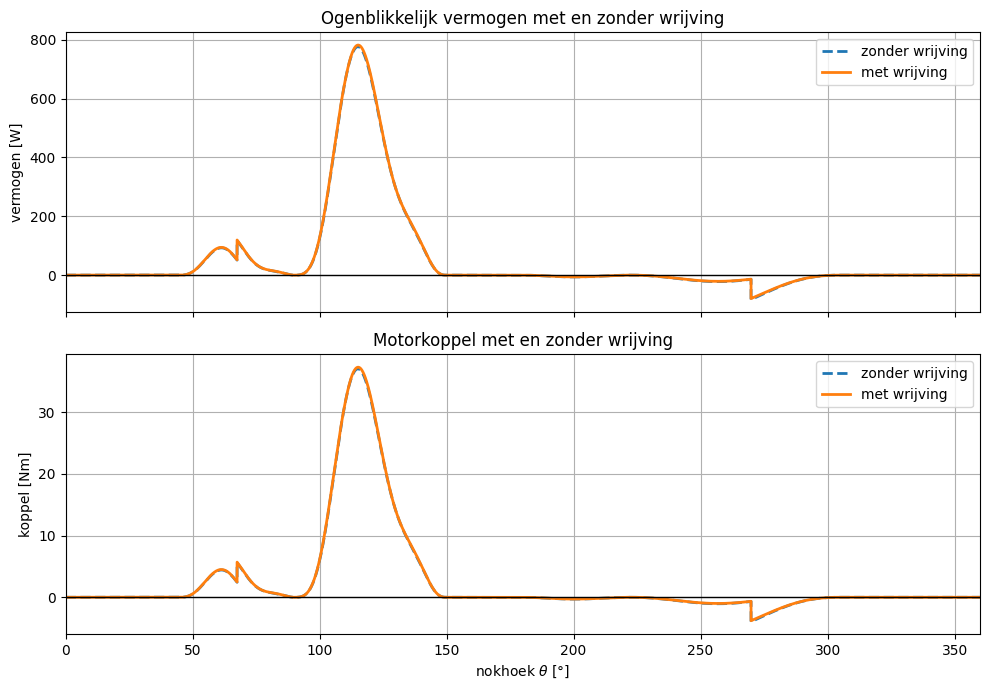

In [33]:
# grafiek vermogen en koppel
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(theta_deg, P_no_friction, linestyle="--", linewidth=2, label="zonder wrijving")
axs[0].plot(theta_deg, P_with_friction, linewidth=2, label="met wrijving")
axs[0].axhline(0, color="black", linewidth=1)
axs[0].set_ylabel("vermogen [W]")
axs[0].set_title("Ogenblikkelijk vermogen met en zonder wrijving")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(theta_deg, T_no_friction, linestyle="--", linewidth=2, label="zonder wrijving")
axs[1].plot(theta_deg, T_with_friction, linewidth=2, label="met wrijving")
axs[1].axhline(0, color="black", linewidth=1)
axs[1].set_xlabel("nokhoek $\\theta$ [°]")
axs[1].set_ylabel("koppel [Nm]")
axs[1].set_title("Motorkoppel met en zonder wrijving")
axs[1].grid(True)
axs[1].legend()

for ax in axs:
    ax.set_xlim(0, 360)

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

metrics_no_friction = performance_metrics(P_no_friction, rpm)
metrics_with_friction = performance_metrics(P_with_friction, rpm)

power_summary = pd.DataFrame([
    {
        "case": "zonder wrijving",
        "P_avg_positive [W]": metrics_no_friction["P_avg_positive"],
        "P_peak [W]": metrics_no_friction["P_peak"],
        "T_peak_abs [Nm]": metrics_no_friction["T_peak_abs"],
        "T_rms [Nm]": metrics_no_friction["T_rms"],
        "E_positive [J/cycle]": metrics_no_friction["E_positive"]
    },
    {
        "case": "met wrijving",
        "P_avg_positive [W]": metrics_with_friction["P_avg_positive"],
        "P_peak [W]": metrics_with_friction["P_peak"],
        "T_peak_abs [Nm]": metrics_with_friction["T_peak_abs"],
        "T_rms [Nm]": metrics_with_friction["T_rms"],
        "E_positive [J/cycle]": metrics_with_friction["E_positive"]
    }
])

display(power_summary.round(2))

,case,P_avg_positive [W],P_peak [W],T_peak_abs [Nm],T_rms [Nm],E_positive [J/cycle]
0,zonder wrijving,56.89,776.19,37.06,8.05,17.07
1,met wrijving,57.38,781.72,37.32,8.11,17.21


**Interpretatie:** Wrijving verhoogt vooral de vermogens- en koppelpiek op de momenten waar grote normaalkracht samenvalt met grote snelheid. De positieve energie per cyclus is de meest bruikbare maat voor energieverbruik wanneer er geen regeneratie wordt aangenomen. Het piekvermogen en piekkoppel zijn belangrijker voor de keuze van een motor dan het gesigneerde gemiddelde vermogen.

## 4.2 Parameterstudie: invloed van toerental

We houden het finale nokprofiel, de veer en de excentriciteit constant. Alleen het toerental wordt aangepast. Zo onderzoeken we wat er gebeurt als dezelfde machine sneller draait. De externe belasting en veerkracht veranderen niet rechtstreeks met toerental. De inertiekracht verandert wel, omdat deze schaalt met $\omega^2$. Het vermogen stijgt bovendien door de hogere hoeksnelheid. Daarom kan sneller draaien veel zwaarder zijn dan je zou denken met een lineaire schaalfactor.

In [35]:
def evaluate_design_at_rpm(rpm_value):
    pa = calculatePressureAngle(vel, exc_final, base_radius, Rr, lift)

    N, fx, fy, F_friction = calculateForce_with_friction(
        rpm_value,
        lift,
        vel,
        spring_constant,
        spring_preload,
        pa,
        ext_load,
        mass,
        acc
    )

    P = calculateInstantaneousPower(
        rpm_value,
        pa,
        N,
        exc_final,
        lift,
        base_radius,
        Rr
    )

    metrics = performance_metrics(P, rpm_value)

    return {
        "rpm": rpm_value,
        "N_min [N]": np.min(N),
        "N_max [N]": np.max(N),
        "F_friction_max [N]": np.max(np.abs(F_friction)),
        "P_avg_positive [W]": metrics["P_avg_positive"],
        "P_peak [W]": metrics["P_peak"],
        "T_peak_abs [Nm]": metrics["T_peak_abs"],
        "T_rms [Nm]": metrics["T_rms"],
        "E_positive [J/cycle]": metrics["E_positive"]
    }


rpm_values = np.array([100, 150, 200, 250, 300, 350, 400])

rpm_results = pd.DataFrame([
    evaluate_design_at_rpm(rpm_value)
    for rpm_value in rpm_values
])

display(rpm_results.round(2))

,rpm,N_min [N],N_max [N],F_friction_max [N],P_avg_positive [W],P_peak [W],T_peak_abs [Nm],T_rms [Nm],E_positive [J/cycle]
0,100,-68.44,1656.97,37.99,28.92,342.33,32.69,7.86,17.35
1,150,-12.93,1656.97,37.99,43.04,526.36,33.51,7.86,17.22
2,200,0.00,1656.97,37.99,57.38,781.72,37.32,8.11,17.21
3,250,-92.34,1820.52,37.99,73.72,1148.16,43.86,8.80,17.69
4,300,-284.62,2288.06,37.99,95.14,1653.84,52.64,10.09,19.03
5,350,-756.76,2842.38,45.96,129.21,2325.29,63.44,12.03,22.15
6,400,-1394.81,3482.85,55.93,175.07,3189.07,76.13,14.62,26.26


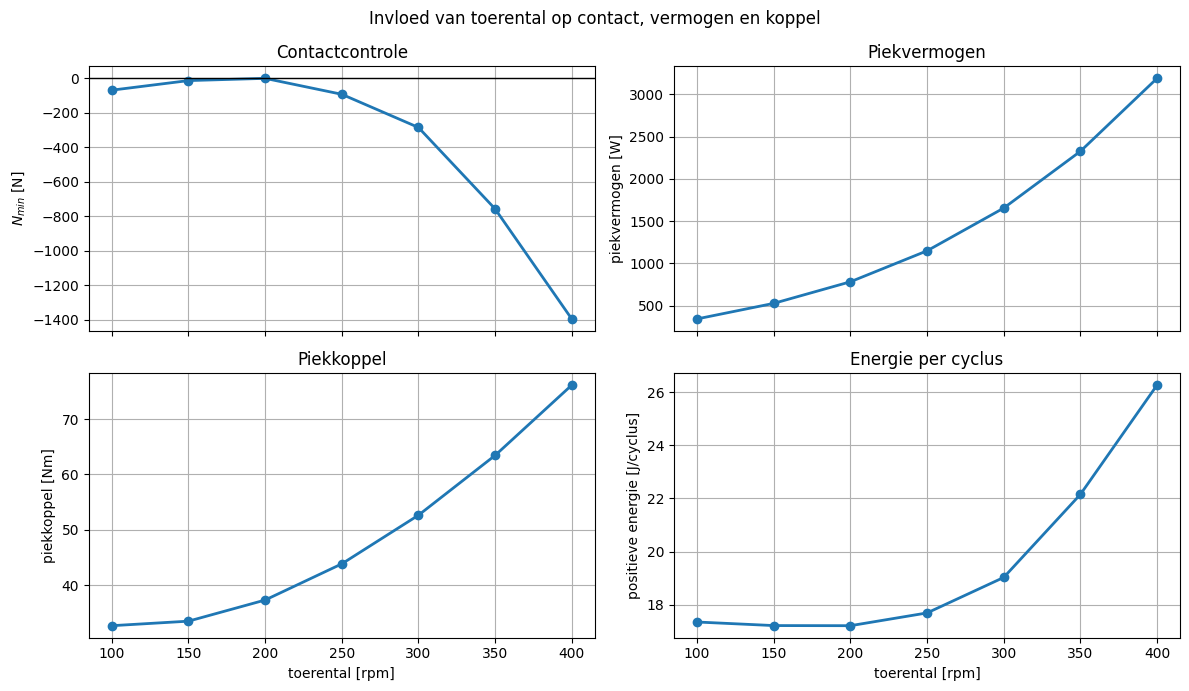

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

axs[0, 0].plot(rpm_results["rpm"], rpm_results["N_min [N]"], marker="o", linewidth=2)
axs[0, 0].axhline(0, color="black", linewidth=1)
axs[0, 0].set_ylabel("$N_{min}$ [N]")
axs[0, 0].set_title("Contactcontrole")
axs[0, 0].grid(True)

axs[0, 1].plot(rpm_results["rpm"], rpm_results["P_peak [W]"], marker="o", linewidth=2)
axs[0, 1].set_ylabel("piekvermogen [W]")
axs[0, 1].set_title("Piekvermogen")
axs[0, 1].grid(True)

axs[1, 0].plot(rpm_results["rpm"], rpm_results["T_peak_abs [Nm]"], marker="o", linewidth=2)
axs[1, 0].set_xlabel("toerental [rpm]")
axs[1, 0].set_ylabel("piekkoppel [Nm]")
axs[1, 0].set_title("Piekkoppel")
axs[1, 0].grid(True)

axs[1, 1].plot(rpm_results["rpm"], rpm_results["E_positive [J/cycle]"], marker="o", linewidth=2)
axs[1, 1].set_xlabel("toerental [rpm]")
axs[1, 1].set_ylabel("positieve energie [J/cyclus]")
axs[1, 1].set_title("Energie per cyclus")
axs[1, 1].grid(True)

plt.suptitle("Invloed van toerental op contact, vermogen en koppel")
plt.tight_layout()
plt.show()

**Interpretatie:** Bij hoger toerental neemt vooral de inertiebijdrage toe. Daardoor stijgen normaalkracht, wrijvingskracht en piekvermogen. Als $N_{min}$ negatief wordt, is het ontwerp bij dat toerental niet meer geldig omdat de volger contact verliest. Deze studie toont dus vanaf welk toerental sneller draaien mechanisch ongunstig wordt. Natuurlijk zouden we voor die toerentallen onze veren kunnen aanpassen maar dit toont wel aan dat ons systeem voor een bepaald toerental geoptimaliseerd is.

## 4.3 Parameterstudie: parallelle kopieën

Een alternatief voor sneller draaien is meerdere kopieën van hetzelfde nokmechanisme parallel laten werken met een faseverschuiving. Het gemiddelde vermogen stijgt dan ongeveer evenredig met het aantal kopieën, maar de vermogenspieken kunnen beter gespreid worden. Dit lijkt op het principe van een rotary tablet press, waarbij meerdere tabletten per omwenteling geproduceerd worden. In deze studie vergelijken we één, twee, drie en vier identieke nokken die gelijkmatig over de cyclus uit fase staan.

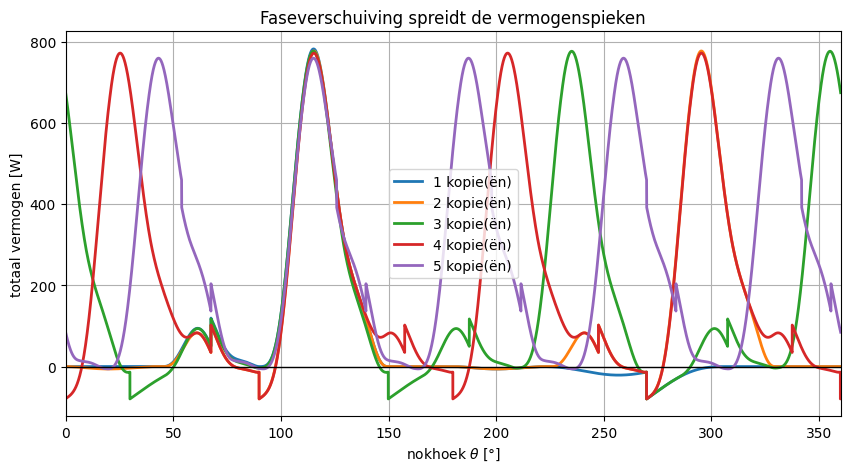

,aantal kopieën,capaciteit [cycli/h],P_avg_positive [W],P_peak [W],T_peak_abs [Nm],E_positive [J/cycle totaal],peak/avg
0,1,12000,57.38,781.72,37.32,17.21,13.62
1,2,24000,109.02,776.72,37.09,32.71,7.12
2,3,36000,165.95,776.04,37.05,49.78,4.68
3,4,48000,216.65,771.48,36.84,64.99,3.56
4,5,60000,264.16,759.00,36.24,79.25,2.87


In [37]:
def shift_periodic(signal, phase_deg):
    shifted_theta = (theta_deg - phase_deg) % 360
    return np.interp(shifted_theta, theta_deg, signal, period=360)


def total_parallel_signal(signal, n_copies):
    phases = np.linspace(0, 360, n_copies, endpoint=False)
    total = np.zeros_like(signal)

    for phase in phases:
        total += shift_periodic(signal, phase)

    return total


parallel_cases = [1, 2, 3, 4, 5]

parallel_results = []

plt.figure(figsize=(10, 5))

for n in parallel_cases:
    P_total = total_parallel_signal(P_with_friction, n)
    metrics = performance_metrics(P_total, rpm)

    capacity_per_hour = n * rpm * 60

    parallel_results.append({
        "aantal kopieën": n,
        "capaciteit [cycli/h]": capacity_per_hour,
        "P_avg_positive [W]": metrics["P_avg_positive"],
        "P_peak [W]": metrics["P_peak"],
        "T_peak_abs [Nm]": metrics["T_peak_abs"],
        "E_positive [J/cycle totaal]": metrics["E_positive"],
        "peak/avg": metrics["P_peak"] / metrics["P_avg_positive"]
    })

    plt.plot(theta_deg, P_total, linewidth=2, label=f"{n} kopie(ën)")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("nokhoek $\\theta$ [°]")
plt.ylabel("totaal vermogen [W]")
plt.title("Faseverschuiving spreidt de vermogenspieken")
plt.xlim(0, 360)
plt.grid(True)
plt.legend()
plt.show()

parallel_results = pd.DataFrame(parallel_results)
display(parallel_results.round(2))

**Interpretatie:** Meerdere kopieën verhogen het gemiddelde vermogen en de productiecapaciteit, maar door de faseverschuiving worden de pieken beter verdeeld over de cyclus. Dit kan gunstiger zijn dan één mechanisme veel sneller laten draaien, omdat sneller draaien de inertiekrachten sterk verhoogt. Het nadeel van parallelle kopieën is dat de machine groter, duurder en complexer wordt.

De commerciële referentie [4](#ref4) haalt hoge productiecapaciteit vooral door meerdere stations te gebruiken. Ons ontwerp is dus geen directe vervanging voor een industriële tabletpers, maar de parameterstudie toont hetzelfde principe: parallelle, faseverschoven compressies kunnen de capaciteit verhogen zonder dat elk individueel mechanisme sneller moet bewegen.

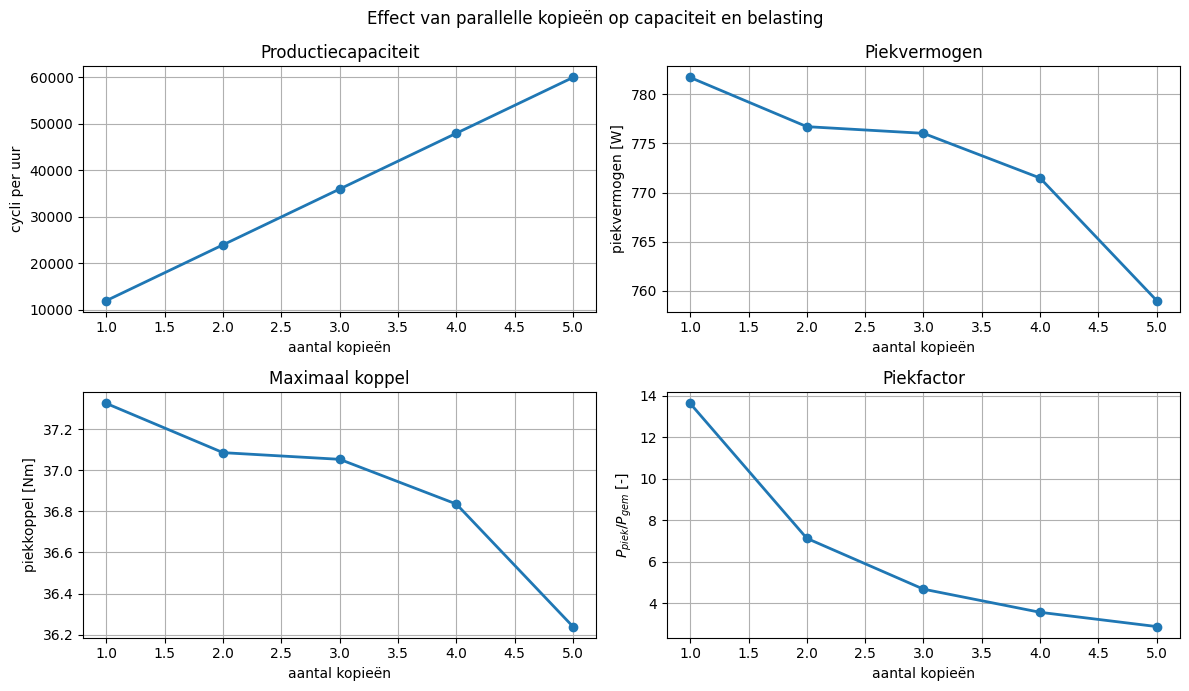

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

axs[0, 0].plot(parallel_results["aantal kopieën"],
               parallel_results["capaciteit [cycli/h]"],
               marker="o", linewidth=2)
axs[0, 0].set_title("Productiecapaciteit")
axs[0, 0].set_ylabel("cycli per uur")
axs[0, 0].set_xlabel("aantal kopieën")
axs[0, 0].grid(True)

axs[0, 1].plot(parallel_results["aantal kopieën"],
               parallel_results["P_peak [W]"],
               marker="o", linewidth=2)
axs[0, 1].set_title("Piekvermogen")
axs[0, 1].set_ylabel("piekvermogen [W]")
axs[0, 1].set_xlabel("aantal kopieën")
axs[0, 1].grid(True)

axs[1, 0].plot(parallel_results["aantal kopieën"],
               parallel_results["T_peak_abs [Nm]"],
               marker="o", linewidth=2)
axs[1, 0].set_title("Maximaal koppel")
axs[1, 0].set_ylabel("piekkoppel [Nm]")
axs[1, 0].set_xlabel("aantal kopieën")
axs[1, 0].grid(True)

axs[1, 1].plot(parallel_results["aantal kopieën"],
               parallel_results["peak/avg"],
               marker="o", linewidth=2)
axs[1, 1].set_title("Piekfactor")
axs[1, 1].set_ylabel("$P_{piek}/P_{gem}$ [-]")
axs[1, 1].set_xlabel("aantal kopieën")
axs[1, 1].grid(True)

plt.suptitle("Effect van parallelle kopieën op capaciteit en belasting")
plt.tight_layout()
plt.show()

**Interpretatie:** Meer parallelle kopieën verhogen de productiecapaciteit bijna lineair. Door de faseverschuiving worden de vermogenspieken beter gespreid, waardoor de piekfactor daalt. Het voordeel blijft echter niet onbeperkt toenemen: bij veel kopieën stijgt het gemiddelde vermogen en wordt de machine groter en complexer. De limiterende factoren worden dan vooral het gemiddelde motorvermogen, het maximale askoppel, de constructiegrootte en de mechanische synchronisatie.

## 4.4 Aanpassing aan andere toepassingen
Het ontwerp kan aangepast worden aan andere tabletten of andere compressietoepassingen. Bij een grotere tablet of hogere gewenste compressiekracht moet het externe krachtprofiel verhoogd worden. Daardoor stijgen de normaalkracht, het koppel en het vermogen. Mogelijk moeten dan ook de pitch radius, rolvolgerstraal, veer en motor groter gekozen worden.

Bij een langere dwell blijft de tablet langer onder maximale compressie. Dit kan gunstig zijn voor de vorming van de tablet, maar het laat minder hoekruimte over voor de intrede en terugkeer. Daardoor kunnen snelheid, versnelling en drukhoek in de overige segmenten toenemen.

Bij een hogere productiecapaciteit zijn er twee mogelijkheden: het toerental verhogen of meerdere kopieën parallel gebruiken. Sneller draaien is compact, maar verhoogt inertiekrachten en piekvermogen. Parallelle kopieën maken de machine groter en complexer, maar kunnen de vermogenspieken beter spreiden.


## 4.5 Precisie vs krachtgeneratie vs energieverbruik

De ontwerpkeuzes hangen af van wat het belangrijkste doel is: precisie, krachtgeneratie of energieverbruik. Deze doelen zijn niet volledig onafhankelijk.

| Doel | Hoe verbeteren? | Mogelijk nadeel |
|---|---|---|
| Precisie | lagere drukhoek, stijvere geleiding, langere dwell, lagere snelheid | grotere nok, lager productietempo, hogere constructiekost |
| Krachtgeneratie | hogere motorreserve, sterkere nok, hogere voorspanning, grotere contactoppervlakken | hogere normaalkracht, meer slijtage, meer energieverbruik |
| Energieverbruik | lagere wrijving, gunstige excentriciteit, lagere onnodige veerkracht, parallelle spreiding van pieken | mogelijk grotere constructie of lagere krachtmarge |
| Lage piekbelasting | grotere segmenthoeken, vloeiender profiel, meerdere kopieën uit fase | langere cyclus of grotere machine |

Voor onze toepassing is contactbehoud de harde voorwaarde. Daarna zoeken we een compromis tussen beperkte drukhoek, voldoende compressiekracht en beperkt wrijvingsverlies. De gekozen excentriciteit is daarom geen universeel optimum, maar een optimum voor het gekozen criterium: minimaal wrijvingswerk met behoud van contact en drukhoeklimiet.

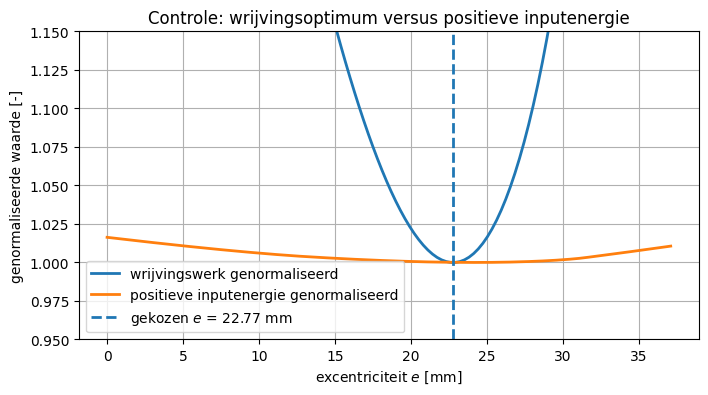

,e [mm],max alpha [°],min N [N],wrijvingswerk [Nmm],E_positive [J/cycle],P_peak [W],T_peak_abs [Nm]
0,0.00,18.76,0.0,442.95,17.49,801.97,38.29
1,7.00,15.88,0.0,324.99,17.36,795.64,37.99
2,22.77,25.64,0.0,202.65,17.21,781.72,37.32
3,40.00,36.91,0.0,491.75,17.47,787.32,37.59


In [39]:
def friction_work_raw_for_plot(e):
    pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

    N, fx, fy, F_friction = calculateForce_with_friction(
        rpm,
        lift,
        vel,
        spring_constant,
        spring_preload,
        pa,
        ext_load,
        mass,
        acc
    )

    max_alpha = np.max(np.abs(np.rad2deg(pa)))
    min_N = np.min(N)

    if min_N < 0 or max_alpha > 35:
        return np.nan

    integrand = np.abs(F_friction) * np.abs(vel)
    return np.trapezoid(integrand, theta)


def positive_energy_for_e(e):
    pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

    N, fx, fy, F_friction = calculateForce_with_friction(
        rpm,
        lift,
        vel,
        spring_constant,
        spring_preload,
        pa,
        ext_load,
        mass,
        acc
    )

    max_alpha = np.max(np.abs(np.rad2deg(pa)))
    min_N = np.min(N)

    if min_N < 0 or max_alpha > 35:
        return np.nan

    P = calculateInstantaneousPower(
        rpm,
        pa,
        N,
        e,
        lift,
        base_radius,
        Rr
    )

    return performance_metrics(P, rpm)["E_positive"]


exc_check = np.linspace(0, 0.75 * R0, 200)

J_check = np.array([friction_work_raw_for_plot(e) for e in exc_check])
Epos_check = np.array([positive_energy_for_e(e) for e in exc_check])

J_norm = J_check / np.nanmin(J_check)
Epos_norm = Epos_check / np.nanmin(Epos_check)

plt.figure(figsize=(8, 4))
plt.plot(exc_check, J_norm, linewidth=2, label="wrijvingswerk genormaliseerd")
plt.plot(exc_check, Epos_norm, linewidth=2, label="positieve inputenergie genormaliseerd")
plt.axvline(exc_optimal_friction, linestyle="--", linewidth=2,
            label=f"gekozen $e$ = {exc_optimal_friction:.2f} mm")

plt.xlabel("excentriciteit $e$ [mm]")
plt.ylabel("genormaliseerde waarde [-]")
plt.title("Controle: wrijvingsoptimum versus positieve inputenergie")
plt.ylim(0.95, 1.15)
plt.grid(True)
plt.legend()
plt.show()

#tabel
check_e_values = [
    0,
    exc_optimal_rms,
    exc_optimal_friction,
    40
]

check_rows = []

for e in check_e_values:
    pa = calculatePressureAngle(vel, e, base_radius, Rr, lift)

    N, fx, fy, F_friction = calculateForce_with_friction(
        rpm,
        lift,
        vel,
        spring_constant,
        spring_preload,
        pa,
        ext_load,
        mass,
        acc
    )

    P = calculateInstantaneousPower(
        rpm,
        pa,
        N,
        e,
        lift,
        base_radius,
        Rr
    )

    metrics = performance_metrics(P, rpm)

    integrand = np.abs(F_friction) * np.abs(vel)
    J = np.trapezoid(integrand, theta)

    check_rows.append({
        "e [mm]": e,
        "max alpha [°]": np.max(np.abs(np.rad2deg(pa))),
        "min N [N]": np.min(N),
        "wrijvingswerk [Nmm]": J,
        "E_positive [J/cycle]": metrics["E_positive"],
        "P_peak [W]": metrics["P_peak"],
        "T_peak_abs [Nm]": metrics["T_peak_abs"]
    })

eccentricity_check_table = pd.DataFrame(check_rows)
display(eccentricity_check_table.round(2))

**Interpretatie:** Deze grafiek controleert of de gekozen excentriciteit op basis van wrijvingswerk ook redelijk blijft voor de positieve inputenergie. Als beide minima dicht bij elkaar liggen, is de keuze sterk. Als ze sterk verschillen, is er een trade-off tussen minimale wrijving en minimale motorenergie.

- Blauwe curve = hoe goed is elke excentriciteit qua wrijvingsverlies?
- Oranje curve = hoe goed is elke excentriciteit qua totale positieve inputenergie?
- Verticale lijn = gekozen optimum op basis van wrijvingswerk

<a id="finale-waarden"></a>
# 5. Finale ontwerpwaarden en checklist

## 5.1 Finale ontwerpwaarden

In deze sectie verzamelen we de belangrijkste ontwerpwaarden van het finale nokmechanisme. Dit zijn de waarden die volgen uit het aangepaste bewegingsprofiel, de Kloomok-Muffley-analyse, het veerontwerp, de wrijvingsanalyse en de vermogensanalyse.

In [40]:
# Finale ontwerpwaarden verzamelen

exc_final = exc_optimal_friction

max_alpha_final = np.max(np.abs(np.rad2deg(pressure_angle_opt)))
min_normalforce_final = np.min(normalforce_tot_opt)

# Uit ondersnijdingscontrole
rho_pitch_min_final = min(rho_at_design.values())
rho_cam_min_final = rho_pitch_min_final - Rr

# Uit vermogensanalyse met wrijving
P_avg_positive_final = metrics_with_friction["P_avg_positive"]
P_peak_final = metrics_with_friction["P_peak"]
T_peak_final = metrics_with_friction["T_peak_abs"]
T_rms_final = metrics_with_friction["T_rms"]
E_positive_final = metrics_with_friction["E_positive"]

throughput_1_cam = rpm * 60
throughput_4_parallel = 4 * rpm * 60

final_design_table = pd.DataFrame([
    {"Categorie": "Geometrie", "Grootheid": "Pitch radius R0", "Waarde": R0, "Eenheid": "mm"},
    {"Categorie": "Geometrie", "Grootheid": "Rolvolgerstraal Rr", "Waarde": Rr, "Eenheid": "mm"},
    {"Categorie": "Geometrie", "Grootheid": "Basisstraal Rb", "Waarde": base_radius, "Eenheid": "mm"},
    {"Categorie": "Geometrie", "Grootheid": "Finale excentriciteit e", "Waarde": exc_final, "Eenheid": "mm"},

    {"Categorie": "Nokveer", "Grootheid": "Voorspanning", "Waarde": spring_preload, "Eenheid": "N"},
    {"Categorie": "Nokveer", "Grootheid": "Veerconstante", "Waarde": spring_constant, "Eenheid": "N/mm"},

    {"Categorie": "Validatie", "Grootheid": "Maximale drukhoek", "Waarde": max_alpha_final, "Eenheid": "°"},
    {"Categorie": "Validatie", "Grootheid": "Minimale normaalkracht", "Waarde": min_normalforce_final, "Eenheid": "N"},
    {"Categorie": "Validatie", "Grootheid": "Minimale rho_{pitch}", "Waarde": rho_pitch_min_final, "Eenheid": "mm"},
    {"Categorie": "Validatie", "Grootheid": "Minimale rho_{cam}", "Waarde": rho_cam_min_final, "Eenheid": "mm"},

    {"Categorie": "Prestaties", "Grootheid": "Toerental", "Waarde": rpm, "Eenheid": "rpm"},
    {"Categorie": "Prestaties", "Grootheid": "Positieve energie per cyclus", "Waarde": E_positive_final, "Eenheid": "J/cyclus"},
    {"Categorie": "Prestaties", "Grootheid": "Gemiddeld positief vermogen", "Waarde": P_avg_positive_final, "Eenheid": "W"},
    {"Categorie": "Prestaties", "Grootheid": "Piekvermogen", "Waarde": P_peak_final, "Eenheid": "W"},
    {"Categorie": "Prestaties", "Grootheid": "Piekkoppel", "Waarde": T_peak_final, "Eenheid": "Nm"},
    {"Categorie": "Prestaties", "Grootheid": "RMS-koppel", "Waarde": T_rms_final, "Eenheid": "Nm"},

    {"Categorie": "Throughput", "Grootheid": "Capaciteit met 1 nok", "Waarde": throughput_1_cam, "Eenheid": "cycli/h"},
    {"Categorie": "Throughput", "Grootheid": "Capaciteit met 4 parallelle nokken", "Waarde": throughput_4_parallel, "Eenheid": "cycli/h"},
])

display(final_design_table.round(2))

,Categorie,Grootheid,Waarde,Eenheid
0,Geometrie,Pitch radius R0,80.00,mm
1,Geometrie,Rolvolgerstraal Rr,35.00,mm
2,Geometrie,Basisstraal Rb,45.00,mm
3,Geometrie,Finale excentriciteit e,22.77,mm
4,Nokveer,Voorspanning,291.26,N
5,Nokveer,Veerconstante,19.04,N/mm
6,Validatie,Maximale drukhoek,25.64,°
7,Validatie,Minimale normaalkracht,0.00,N
8,Validatie,Minimale rho_{pitch},48.89,mm
9,Validatie,Minimale rho_{cam},13.89,mm


## 5.2 Validatievoorwaarden

Het ontwerp wordt gevalideerd aan de hand van de belangrijkste mechanische voorwaarden: drukhoek, contactbehoud, ondersnijding, dwell en vermogen. Deze voorwaarden bepalen of het nokmechanisme fysisch realiseerbaar en bruikbaar is voor de gekozen toepassing.

In [41]:
validation_table = pd.DataFrame([
    {
        "Voorwaarde": "Drukhoek beperken",
        "Eis": "|alpha| < 35°",
        "Resultaat": f"{max_alpha_final:.2f}°",
        "Status": "OK" if max_alpha_final < 35 else "Niet OK"
    },
    {
        "Voorwaarde": "Contact behouden",
        "Eis": "N > 0",
        "Resultaat": f"{min_normalforce_final:.3f} N",
        "Status": "OK" if min_normalforce_final >= -1e-6 else "Niet OK"
    },
    {
        "Voorwaarde": "Ondersnijding vermijden",
        "Eis": "rho_{pitch,min} > Rr",
        "Resultaat": f"{rho_pitch_min_final:.2f} mm > {Rr:.2f} mm",
        "Status": "OK" if rho_pitch_min_final > Rr else "Niet OK"
    },
    {
        "Voorwaarde": "Effectieve nokkromtestraal positief",
        "Eis": "rho_{cam,min} > 0",
        "Resultaat": f"{rho_cam_min_final:.2f} mm",
        "Status": "OK" if rho_cam_min_final > 0 else "Niet OK"
    },
    {
        "Voorwaarde": "Dwell aanwezig",
        "Eis": "constante lift op maximale compressie",
        "Resultaat": "aanwezig in aangepast profiel",
        "Status": "OK"
    },
    {
        "Voorwaarde": "Piekvermogen gekend",
        "Eis": "nodig voor motorcontrole",
        "Resultaat": f"{P_peak_final:.2f} W",
        "Status": "OK"
    },
    {
        "Voorwaarde": "Energie per cyclus gekend",
        "Eis": "nodig voor kost/energieanalyse",
        "Resultaat": f"{E_positive_final:.2f} J/cyclus",
        "Status": "OK"
    },
])

display(validation_table)

,Voorwaarde,Eis,Resultaat,Status
0,Drukhoek beperken,|alpha| < 35°,25.64°,OK
1,Contact behouden,N > 0,0.000 N,OK
2,Ondersnijding vermijden,"rho_{pitch,min} > Rr",48.89 mm > 35.00 mm,OK
3,Effectieve nokkromtestraal positief,"rho_{cam,min} > 0",13.89 mm,OK
4,Dwell aanwezig,constante lift op maximale compressie,aanwezig in aangepast profiel,OK
5,Piekvermogen gekend,nodig voor motorcontrole,781.72 W,OK
6,Energie per cyclus gekend,nodig voor kost/energieanalyse,17.21 J/cyclus,OK


In [42]:
commercial_capacity_min = 9000     # PC/h, XYP-5
commercial_capacity_max = 40000    # PC/h, XYP-19
commercial_power_min = 2200        # W
commercial_power_max = 2500        # W
commercial_pressure = 80000        # N, 80 kN

our_capacity_1 = throughput_1_cam
our_capacity_4 = throughput_4_parallel

# Vermogen uit parallel_results voor 4 kopieën, indien beschikbaar
our_parallel_4 = parallel_results[parallel_results["aantal kopieën"] == 4].iloc[0]

benchmark_table = pd.DataFrame([
    {
        "Grootheid": "Aantal stations/kopieën",
        "Ons ontwerp, 1 nok": "1",
        "Ons ontwerp, 4 parallel": "4",
        "Commerciële referentie": "5 tot 19"
    },
    {
        "Grootheid": "Capaciteit [tabletten/h]",
        "Ons ontwerp, 1 nok": f"{our_capacity_1:.0f}",
        "Ons ontwerp, 4 parallel": f"{our_capacity_4:.0f}",
        "Commerciële referentie": "9000 tot 40000"
    },
    {
        "Grootheid": "Max. compressiekracht",
        "Ons ontwerp, 1 nok": f"{np.max(ext_load):.0f} N",
        "Ons ontwerp, 4 parallel": f"{np.max(ext_load):.0f} N per nok",
        "Commerciële referentie": "80 kN"
    },
    {
        "Grootheid": "Positieve energie per cyclus",
        "Ons ontwerp, 1 nok": f"{E_positive_final:.2f} J",
        "Ons ontwerp, 4 parallel": f"{4 * E_positive_final:.2f} J per gezamenlijke cyclus",
        "Commerciële referentie": "niet rechtstreeks gegeven"
    },
    {
        "Grootheid": "Gemiddeld positief vermogen",
        "Ons ontwerp, 1 nok": f"{P_avg_positive_final:.2f} W",
        "Ons ontwerp, 4 parallel": f"{our_parallel_4['P_avg_positive [W]']:.2f} W",
        "Commerciële referentie": "2200 tot 2500 W geïnstalleerd"
    },
    {
        "Grootheid": "Piekvermogen",
        "Ons ontwerp, 1 nok": f"{P_peak_final:.2f} W",
        "Ons ontwerp, 4 parallel": f"{our_parallel_4['P_peak [W]']:.2f} W",
        "Commerciële referentie": "niet rechtstreeks gegeven"
    },
])

display(benchmark_table)

,Grootheid,"Ons ontwerp, 1 nok","Ons ontwerp, 4 parallel",Commerciële referentie
0,Aantal stations/kopieën,1,4,5 tot 19
1,Capaciteit [tabletten/h],12000,48000,9000 tot 40000
2,Max. compressiekracht,1050 N,1050 N per nok,80 kN
3,Positieve energie per cyclus,17.21 J,68.85 J per gezamenlijke cyclus,niet rechtstreeks gegeven
4,Gemiddeld positief vermogen,57.38 W,216.65 W,2200 tot 2500 W geïnstalleerd
5,Piekvermogen,781.72 W,771.48 W,niet rechtstreeks gegeven


## 5.3 Sterktes, beperkingen en mogelijke verbeteringen
| Aspect | Sterkte | Beperking / verbetering |
|---|---|---|
| Bewegingsprofiel | Dwell en gecontroleerde compressie zijn expliciet ingebouwd | Jerk kan nog vloeiender met extra overgangssegmenten |
| Geometrie | Drukhoek en ondersnijding zijn gecontroleerd | Praktisch ontwerp vraagt nog materiaalkeuze en tolerantieanalyse |
| Contact | Nokveer houdt contact over de cyclus | Minimale normaalkracht ligt dicht bij nul; veiligheidsfactor toevoegen |
| Wrijving | Excentriciteit verlaagt wrijvingswerk duidelijk | Wrijvingscoëfficiënt is aangenomen constant |
| Vermogen | Piekvermogen, koppel en energie per cyclus zijn berekend | Motorselectie en vliegwiel worden uitgebreider behandeld bij het stangenmechanisme |
| Productiecapaciteit | Parallelle nokken kunnen throughput verhogen zonder sneller profiel | Meer kopieën maken de machine groter, duurder en complexer |
| Vergelijking industrie | Zelfde principe als rotary press: meerdere stations verhogen capaciteit | Commerciële machines leveren veel hogere kracht en betrouwbaarheid |

<a id="referenties"></a>
# 6. Referenties

<a id="ref1"></a>
[1] Research article die wall friction: https://www.sciencedirect.com/science/article/pii/0032591083870090?fr=RR-2&ref=pdf_download&rr=a0f3901e18301327

<a id="ref2"></a>
[2] Krachten bij tablet compressie: https://www.scribd.com/document/879454686/Various-Forces-in-the-Compression

<a id="ref3"></a>
[3] Tablet compression force: https://www.futek.com/applications/pill-press-force-verification

<a id="ref4"></a>
[4] How tablet compression works: https://www.abbviecontractmfg.com/news-and-insights/fun-science-friday/tableting-vs-encapsulation.html

<a id="ref5"></a>
[5] Voorbeeld tablet copression machine: https://nl.achievechem.com/tablet-press-machines/pill-maker-machine.html

<a id="ref6"></a>
[6] Gif tablet compressie nokkenband: https://en.wikipedia.org/wiki/File:Tablet_press_animation.gif

<a id="ref7"></a>
[7] Energieprijs per kWh Belgie: https://totalenergies.be/nl/particulieren/elektriciteitsprijzen-in-belgie-evolutie-in-kwh
